## 1. Business Understanding
* ### Problem 
  * A real estate company or platform has thousands of residential listings in Gurgaon, but there is no clear understanding of the factors influencing prices or the differences between standard and luxury properties, making pricing decisions and market analysis difficult

* ### Objectives
  * Understand the factors affecting real estate prices.
Analyze the relationship between area and price.
Comparing luxury properties with standard properties.
Study the effect of the number of rooms and floor on the market value.
Extracting insights that support real estate pricing and investment decisions.

## 2. Business Questions
 * What factors have the strongest relationship with property prices?
 * How does property size influence market value?
 * Are luxury properties significantly different from standard properties?
 * Do higher-floor apartments command higher prices?
 * How do bedroom counts affect pricing?
 * Which area measurement type is associated with higher property values?

In [1]:
# Import Libraries
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from scipy import stats


pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_rows = 100
pd.options.display.max_columns = None

In [2]:
# Load Dataset
df = pd.read_csv('flats - flats.csv')

## 3. Data Understanding

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3028 entries, 0 to 3027
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   property_name    3028 non-null   str  
 1   link             3028 non-null   str  
 2   society          3027 non-null   str  
 3   price            3008 non-null   str  
 4   area             3015 non-null   str  
 5   areaWithType     3009 non-null   str  
 6   bedRoom          3009 non-null   str  
 7   bathroom         3009 non-null   str  
 8   balcony          3009 non-null   str  
 9   additionalRoom   1695 non-null   str  
 10  address          3003 non-null   str  
 11  floorNum         3007 non-null   str  
 12  facing           2128 non-null   str  
 13  agePossession    3008 non-null   str  
 14  nearbyLocations  2914 non-null   str  
 15  description      3009 non-null   str  
 16  furnishDetails   2204 non-null   str  
 17  features         2595 non-null   str  
 18  rating           26

In [4]:
df.sample(10)

,property_name,link,society,price,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,property_id
992,3 BHK Flat in Sector 83 Gurgaon,https://www.99acres.com/3-bhk-bedroom-apartmen...,Vatika Lifestyle Homes3.8 ★,1.1 Crore,"₹ 6,267/sq.ft.",Super Built up area 1755(163.04 sq.m.),3 Bedrooms,3 Bathrooms,2 Balconies,"Pooja Room,Study Room,Store Room","Sector 83 Gurgaon, Gurgaon, Haryana",8th of 15 Floors,South,1 to 5 Year Old,"['Sapphire 83 Mall', 'NH – 08', 'Knowledge Tre...","Sector 83 gurgaon, gurgaon, haryana\nThis is a...","['5 Wardrobe', '6 Fan', '1 Exhaust Fan', '3 Ge...","['Centrally Air Conditioned', 'Water purifier'...","['Green Area4.5 out of 5', 'Construction4 out ...",Y69590980
1232,3 BHK Flat in Sector 37D Gurgaon,https://www.99acres.com/3-bhk-bedroom-apartmen...,Ramprastha The Edge Towers3.5 ★,98 Lac,"₹ 5,536/sq.ft.",Super Built up area 1770(164.44 sq.m.)Built Up...,3 Bedrooms,3 Bathrooms,3+ Balconies,Pooja Room,"K400, Sector 37D Gurgaon, Gurgaon, Haryana",5th of 19 Floors,North-East,1 to 5 Year Old,"['MDS Public School', 'St Pauls School', 'Sunc...","Expressway facing balcony, a 3bhk flat in sect...",NaN,"['Centrally Air Conditioned', 'Water purifier'...","['Green Area4 out of 5', 'Construction4 out of...",E61449810
837,2 BHK Flat in Sector 74 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,M3M Skywalk,1.6 Crore,"₹ 9,512/sq.ft.",Super Built up area 1682(156.26 sq.m.)Carpet a...,2 Bedrooms,2 Bathrooms,2 Balconies,NaN,"Sector 74 Gurgaon, Gurgaon, Haryana",26th of 30 Floors,South,1 to 5 Year Old,"['Omaxe Gurgaon Mall', 'Omaxe Celebration Mall...",Beautiful property hygiene property neat and c...,"['1 Water Purifier', '4 Fan', '1 Exhaust Fan',...","['Water purifier', 'Security / Fire Alarm', 'F...",NaN,N69658358
2767,2 BHK Flat in Sector 78 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,NaN,60 Lac,"₹ 3,692/sq.ft.",Built Up area: 1625 (150.97 sq.m.),2 Bedrooms,2 Bathrooms,No Balcony,NaN,"Gurgaon, Sector 78 Gurgaon, Gurgaon, Haryana",NaN,NaN,Under Construction,NaN,The property is under construction it's by rah...,[],NaN,"['Safety4 out of 5', 'Lifestyle4 out of 5', 'E...",T8073153
2576,4 BHK Flat in Adarsh Nagar,https://www.99acres.com/4-bhk-bedroom-apartmen...,Lord Krishna,2.7 Crore,"₹ 8,571/sq.ft.",Built Up area: 3150 (292.64 sq.m.),4 Bedrooms,3 Bathrooms,3 Balconies,NaN,"Adarsh Nagar, Sector 12a, Adarsh Nagar, Gurgao...",6th of 6 Floors,North-East,undefined,"['Huda city centre metro station', 'Hanuman Ma...",This 4 bhk flat is located in lord krishna cgh...,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,NaN,Z68946778
1092,3 BHK Flat in Sector 49 Gurgaon,https://www.99acres.com/3-bhk-bedroom-apartmen...,Vatika City4.1 ★,2.65 Crore,"₹ 11,770/sq.ft.",Super Built up area 2251.42(209.16 sq.m.)Built...,3 Bedrooms,4 Bathrooms,3 Balconies,"Servant Room,Pooja Room","Vatika City, Sector 49 Gurgaon, Gurgaon, Haryana",11st of 17 Floors,East,5 to 10 Year Old,"['BOB ATM', 'PNB ATM', 'HDFC bank ATM', 'YES b...",A very good fully airconditioned 3bhk plus ser...,"['4 Wardrobe', '6 Fan', '1 Exhaust Fan', '4 Ge...","['Centrally Air Conditioned', 'Water purifier'...","['Green Area5 out of 5', 'Construction4 out of...",H69430168
876,2 BHK Flat in Sector 82 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Vatika The Seven Lamps3.8 ★,85 Lac,"₹ 6,538/sq.ft.",Super Built up area 1300(120.77 sq.m.),2 Bedrooms,2 Bathrooms,2 Balconies,NaN,"Sector 82 Gurgaon, Gurgaon, Haryana",Ground of 16 Floors,East,1 to 5 Year Old,"['SS Omnia Mall', 'Golf Course Ext Rd', 'Knowl...",This 2 bhk apartment is available for sale in ...,"['2 Wardrobe', '4 Fan', '1 Exhaust Fan', '7 Li...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Green Area5 out of 5', 'Construction5 out of...",H69845336
54,2 BHK Flat in Sector 10A Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Maxworth City Residences,80 Lac,"₹ 6,400/sq.f

In [5]:
df['price'].sample(10).unique()

<StringArray>
[    '23 Lac',          nan,   '27.5 Lac',  '1.1 Crore',   '65.5 Lac',
   '55.5 Lac',   '71.2 Lac',  '1.9 Crore', '1.75 Crore', '2.15 Crore']
Length: 10, dtype: str

In [6]:
# Missing Values
missing_report = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': round(df.isnull().mean()*100,2)
})

missing_report.sort_values(
    by='Missing %',
    ascending=False
)

,Missing Count,Missing %
additionalRoom,1333,44.02
facing,900,29.72
furnishDetails,824,27.21
features,433,14.30
rating,351,11.59
nearbyLocations,114,3.76
address,25,0.83
floorNum,21,0.69
agePossession,20,0.66
price,20,0.66


In [7]:
# Duplicate Values
df.duplicated().sum()

np.int64(0)

In [8]:
duplicate_ids = df['property_id'].duplicated().sum()

print(f"Duplicate Property IDs: {duplicate_ids}")

Duplicate Property IDs: 152


While no fully duplicated records were detected, duplicate values were identified within the property_id field. Since this column is expected to uniquely identify each property, further investigation was conducted to determine whether the duplicates represent data-entry issues, repeated listings, or legitimate property updates.

In [9]:
duplicate_properties = df[
    df['property_id'].duplicated(keep=False)
]

duplicate_properties

,property_name,link,society,price,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,property_id
260,2 BHK Flat in Sector 90 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,MRG World Ultimus,50 Lac,"₹ 6,983/sq.ft.",Carpet area: 716 (66.52 sq.m.),2 Bedrooms,2 Bathrooms,2 Balconies,NaN,"Sector 90 Gurgaon, Gurgaon, Haryana",1st of 14 Floors,North-East,Mar 2024,"['Huda Metro Station', 'Aanyaz Mall', 'Sector ...","Best location, beside property 200 bed running...",NaN,"['Lift(s)', 'Maintenance Staff', 'Water Storag...","['Environment4 out of 5', 'Safety5 out of 5', ...",K68195520
266,2 BHK Flat in Sector 99 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Assotech Blith,92 Lac,"₹ 6,739/sq.ft.",Super Built up area 1365(126.81 sq.m.),2 Bedrooms,2 Bathrooms,3+ Balconies,NaN,"Sector 99 Gurgaon, Gurgaon, Haryana",22nd of 24 Floors,NaN,By 2023,"['Huda Metro Station (Gurugram)', 'Dwarka Expr...",Right on dwarkaexpressway near metro station s...,[],"['Private Garden / Terrace', 'Lift(s)', 'Swimm...","['Environment4.5 out of 5', 'Safety4.5 out of ...",K68182666
269,2 BHK Flat in Sector 79 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Supertech Araville,71.5 Lac,"₹ 6,061/sq.ft.",Super Built up area 1295(120.31 sq.m.)Carpet a...,2 Bedrooms,2 Bathrooms,3+ Balconies,Others,"E 1706, Sector 79 Gurgaon, Gurgaon, Haryana",17th of 17 Floors,North,0 to 1 Year Old,"['Petrol Pump Indian Oil', 'Petrol Pump', 'Rao...",This is your chance to own a 2 bhk residential...,"['2 Wardrobe', '2 Geyser', '1 Light', '2 AC', ...","['Intercom Facility', 'Lift(s)', 'Maintenance ...","['Environment4 out of 5', 'Safety4 out of 5', ...",Y61729236
270,2 BHK Flat in Sector 103 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Ansal Housing Highland Park,87.5 Lac,"₹ 6,429/sq.ft.",Super Built up area 1361(126.44 sq.m.),2 Bedrooms,2 Bathrooms,3 Balconies,NaN,"Sector 103 Gurgaon, Gurgaon, Haryana",3rd of 12 Floors,NaN,0 to 1 Year Old,"['State bank ATM', 'Dr. Hitesh Dawar', 'Bhardw...",Residential apartment for sell.The property ha...,NaN,"['Intercom Facility', 'Lift(s)', 'Swimming Poo...","['Environment4 out of 5', 'Safety4 out of 5', ...",E56157708
272,3 BHK Flat in Sector 82 Gurgaon,https://www.99acres.com/3-bhk-bedroom-apartmen...,Mapsko Casa Bella3.8 ★,1.25 Crore,"₹ 6,377/sq.ft.",Super Built up area 1960(182.09 sq.m.),3 Bedrooms,4 Bathrooms,3+ Balconies,NaN,"Sector 82 Gurgaon, Gurgaon, Haryana",8th of 19 Floors,NaN,By 2023,"['Vatika City Centre Mall', 'Pataudi Road', 'B...",We are the proud owners of this 3 bhk apartmen...,[],NaN,"['Green Area4.5 out of 5', 'Amenities4 out of ...",W68087548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999,2 BHK Flat in Sector 79 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Supertech Araville,NaN,"₹ 9,000/sq.ft.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3000,3 BHK Flat in Sector 37C Gurgaon,https://www.99acres.com/3-bhk-bedroom-apartmen...,Corona Optus3.9 ★,NaN,"₹ 6,361/sq.ft.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3001,3 BHK Flat in Sector 78 Gurgaon,https://www.99acres.com/3-bhk-bedroom-apartmen...,Umang Monsoon Breeze,NaN,"₹ 6,493/sq.ft.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3002,3 BHK Flat in Sector 88A Gurgaon,https://www.99acres.com/3-bhk-bedroom-apartmen...,Godrej Oasis3.9 ★,NaN,"₹ 8,108/sq.ft.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Invalid Values 
df[df['price'].isnull()]

,property_name,link,society,price,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,property_id
18,2 BHK Flat in Sector 93 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Signature Global Orchard Avenue 2,NaN,NaN,Carpet area: 577.11 (53.62 sq.m.),2 Bedrooms,2 Bathrooms,3 Balconies,NaN,"L-1104, Sector 93 Gurgaon, Gurgaon, Haryana",11st of 14 Floors,East,Under Construction,"['Huda Metro Station', 'V3S Sapphire Ninety', ...",Looking for a budget-Friendly 2 bhk flat in a ...,NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",NaN,H68815396
2850,2 BHK Flat in Sector 107 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Signature Global Solera3.7 ★,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2851,4 BHK Flat in Sector 53 Gurgaon,https://www.99acres.com/4-bhk-bedroom-apartmen...,Tulip Monsella,NaN,"₹ 33,198/sq.ft.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2852,2 BHK Flat in New Palam Vihar,https://www.99acres.com/2-bhk-bedroom-apartmen...,My Home,NaN,"₹ 4,400/sq.ft.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2853,2 BHK Flat in Sohna,https://www.99acres.com/2-bhk-bedroom-apartmen...,Breez Global Hill View,NaN,"₹ 5,470/sq.ft.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2923,3 BHK Flat in Sector 99A Gurgaon,https://www.99acres.com/3-bhk-bedroom-apartmen...,Pareena Coban Residences,NaN,"₹ 5,759/sq.ft.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2924,1 BHK Flat in Golf Course Ext Road,https://www.99acres.com/1-bhk-bedroom-apartmen...,ikon tower baani city centre,NaN,"₹ 12,437/sq.ft.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2925,2 BHK Flat in Sector 89 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Greenopolis,NaN,"₹ 4,820/sq.ft.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2927,4 BHK Flat in C Block Sushant Lok Phase 1,https://www.99acres.com/4-bhk-bedroom-apartmen...,Maple Heights,NaN,"₹ 8,888/sq.ft.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2928,2 BHK Flat in Sector 99 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Assotech Blith,NaN,"₹ 6,593/sq.ft.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.rename(
    columns={'area':'price_per_sqft'},
    inplace=True
)

A preliminary review of the data revealed that most columns were stored as text and required cleaning before analysis. The data also contained diverse property information such as price, area, location, floor, and amenities, making it suitable for studying factors influencing property prices

## 4. Data Quality Assessment

In [12]:
df[df.isnull().any(axis=1)]

,property_name,link,society,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,property_id
0,2 BHK Flat in Krishna Colony,https://www.99acres.com/2-bhk-bedroom-apartmen...,maa bhagwati residency,45 Lac,"₹ 5,000/sq.ft.",Carpet area: 900 (83.61 sq.m.),2 Bedrooms,2 Bathrooms,1 Balcony,NaN,"Krishna Colony, Gurgaon, Haryana",4th of 4 Floors,West,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Pear...",So with lift.Maa bhagwati residency is one of ...,"['3 Fan', '4 Light', '1 Wardrobe', 'No AC', 'N...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Environment4 out of 5', 'Safety4 out of 5', ...",C68850746
1,2 BHK Flat in Ashok Vihar,https://www.99acres.com/2-bhk-bedroom-apartmen...,Apna Enclave,50 Lac,"₹ 7,692/sq.ft.",Carpet area: 650 (60.39 sq.m.),2 Bedrooms,2 Bathrooms,1 Balcony,NaN,"46b, Ashok Vihar, Gurgaon, Haryana",1st of 3 Floors,West,10+ Year Old,"['Chintapurni Mandir', 'Sheetla Mata Mandir', ...","Property situated on main road, railway statio...","['3 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Ge...","['Security / Fire Alarm', 'Maintenance Staff',...","['Environment4 out of 5', 'Safety4 out of 5', ...",H68850564
2,2 BHK Flat in Sohna,https://www.99acres.com/2-bhk-bedroom-apartmen...,Tulsiani Easy in Homes,40 Lac,"₹ 6,722/sq.ft.",Carpet area: 595 (55.28 sq.m.),2 Bedrooms,2 Bathrooms,3 Balconies,NaN,"Sohna, Gurgaon, Haryana",12nd of 14 Floors,NaN,0 to 1 Year Old,"['Huda City Metro', 'Golf Course extn road', '...","This property is 15 km away from badshapur, gu...",NaN,"['Power Back-up', 'Feng Shui / Vaastu Complian...","['Environment4 out of 5', 'Safety4 out of 5', ...",J68850120
3,2 BHK Flat in Sector 61 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Smart World Orchard,1.47 Crore,"₹ 12,250/sq.ft.",Carpet area: 1200 (111.48 sq.m.),2 Bedrooms,2 Bathrooms,2 Balconies,Study Room,"Sector 61 Gurgaon, Gurgaon, Haryana",2nd of 4 Floors,NaN,Dec 2023,"['Sector 55-56 Metro station', 'Bestech Centra...",Near to metro station of sector 56 and opposit...,NaN,"['Security / Fire Alarm', 'Private Garden / Te...",NaN,S68849476
4,2 BHK Flat in Sector 92 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Parkwood Westend,70 Lac,"₹ 5,204/sq.ft.",Super Built up area 1345(124.95 sq.m.),2 Bedrooms,2 Bathrooms,3 Balconies,Study Room,"Sector 92 Gurgaon, Gurgaon, Haryana",5th of 8 Floors,NaN,Under Construction,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...",We are the proud owners of this 2 bhk alongwit...,[],NaN,"['Environment5 out of 5', 'Safety3 out of 5', ...",L47956793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3022,2 BHK Flat in DLF Phase 4,https://www.99acres.com/2-bhk-bedroom-apartmen...,DLF Regency Park 13.6 ★,1.35 Crore,"₹ 11,992/sq.ft.",Built Up area: 1109 (103.03 sq.m.),2 Bedrooms,2 Bathrooms,2 Balconies,NaN,"DLF Phase 4, Gurgaon, Haryana",1st of 26 Floors,NaN,5 to 10 Year Old,"['Sector 42-43 metro station', 'Dlf phase 1 me...",Interested to sell residential apartment . It ...,[],NaN,"['Management5 out of 5', 'Green Area5 out of 5...",M27000679
3023,3 BHK Flat in Sector 86 Gurgaon,https://www.99acres.com/3-bhk-bedroom-apartmen...,Ansal Heights 86,1.05 Crore,"₹ 5,541/sq.ft.",Super Built up area 1895(176.05 sq.m.),3 Bedrooms,3 Bathrooms,3 Balconies,Servant Room,"Tower C, Sector 86 Gurgaon, Gurgaon, Haryana",9th of 13 Floors,North-East,Under Construction,"['IRIS Broadway Mall', 'Delhi Jaipur Expresswa...",Residential apartment for sell.Located in sect...,[],NaN,"['Safety4.5 out of 5', 'Lifestyle5 out of 5', ...",D26586124
3024,5 BHK Flat in Sector 48 Gurgaon,https://www.99acres.com/5-bhk-bedroom-apartmen...,Parsvnath Green Ville3.9 ★,3.3 Crore,"₹ 9,984/sq.ft.",Super Built up area 3905(362.79 sq.m.)Built Up...,5 Bedrooms,5 Bathrooms,3+ Balconies,Servant Room,"Sector 48 Gurgaon, Gurgaon, Haryana",4th of 5 Floors,NaN,10+ Year Old,"['Sri Radhe Kris

In [13]:
duplicate_ids = df[
    df['property_id'].duplicated(keep=False)
].sort_values('property_id')

duplicate_ids[
    ['property_id',
     'property_name',
     'price',
     'address']
]

,property_id,property_name,price,address
2475,A59296758,4 BHK Flat in Sector 95 Gurgaon,1.1 Crore,"Block- G, Sector 95 Gurgaon, Gurgaon, Haryana"
2604,A59296758,4 BHK Flat in Sector 95 Gurgaon,1.1 Crore,"Block- G, Sector 95 Gurgaon, Gurgaon, Haryana"
2578,A68942872,3 BHK Flat in Sector 78 Gurgaon,1.15 Crore,"Sector 78 Gurgaon, Gurgaon, Haryana"
2688,A68942872,3 BHK Flat in Sector 78 Gurgaon,1.15 Crore,"Sector 78 Gurgaon, Gurgaon, Haryana"
2571,A68959646,4 BHK Flat in Sector 24 Gurgaon,14 Crore,"Sector 24, Sector 24 Gurgaon, Gurgaon, Haryana"
...,...,...,...,...
2999,NaN,2 BHK Flat in Sector 79 Gurgaon,NaN,NaN
3000,NaN,3 BHK Flat in Sector 37C Gurgaon,NaN,NaN
3001,NaN,3 BHK Flat in Sector 78 Gurgaon,NaN,NaN
3002,NaN,3 BHK Flat in Sector 88A Gurgaon,NaN,NaN


In [14]:
df = df.drop_duplicates(
    subset=['property_id']
)

In [15]:
df.dropna(subset='price',inplace=True)
df.dropna(subset= ['property_id'] , inplace= True)
df.dropna(subset='price_per_sqft',inplace=True)

In [16]:
# Missing Value Treatment

df['additionalRoom'] = df['additionalRoom'].fillna('No Additional Room')
df['facing'] = df['facing'].fillna('Unknown')
df['features'] = df['features'].fillna('Not Specified')
df['rating'] = df['rating'].fillna('Unknown')
df['nearbyLocations'] = df['nearbyLocations'].fillna('Not Specified')
df['address'] = df['address'].fillna('Not Specified')
df['floorNum'] = df['floorNum'].fillna('Not Specified')
df['agePossession'] = df['agePossession'].fillna('Unknown')
df['society'] = df['society'].fillna('Not Specified')
df['furnishDetails'] = df['furnishDetails'].fillna('Unknown')

In [17]:
df['property_id'].isnull().sum()

np.int64(0)

The data quality was checked to detect missing values, duplicates, and potential issues. No completely duplicate rows were found, but some duplicate Property IDs were identified and reviewed. Missing values ​​were also found in some descriptive columns and were addressed according to their business implications.

## 5. Data Cleaning 

In [18]:
# Price Cleaning
def convert_price(price):

    if price is None:
        return None

    price = str(price).strip()

    if "Cr" in price:
        return float(price.replace("Crore","").strip()) * 10000000

    elif "Lac" in price:
        return float(price.replace("Lac","").strip()) * 100000

    return None


In [19]:
df["price_clean"] = df["price"].apply(convert_price)
df

,property_name,link,society,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,property_id,price_clean
0,2 BHK Flat in Krishna Colony,https://www.99acres.com/2-bhk-bedroom-apartmen...,maa bhagwati residency,45 Lac,"₹ 5,000/sq.ft.",Carpet area: 900 (83.61 sq.m.),2 Bedrooms,2 Bathrooms,1 Balcony,No Additional Room,"Krishna Colony, Gurgaon, Haryana",4th of 4 Floors,West,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Pear...",So with lift.Maa bhagwati residency is one of ...,"['3 Fan', '4 Light', '1 Wardrobe', 'No AC', 'N...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Environment4 out of 5', 'Safety4 out of 5', ...",C68850746,"4,500,000.00"
1,2 BHK Flat in Ashok Vihar,https://www.99acres.com/2-bhk-bedroom-apartmen...,Apna Enclave,50 Lac,"₹ 7,692/sq.ft.",Carpet area: 650 (60.39 sq.m.),2 Bedrooms,2 Bathrooms,1 Balcony,No Additional Room,"46b, Ashok Vihar, Gurgaon, Haryana",1st of 3 Floors,West,10+ Year Old,"['Chintapurni Mandir', 'Sheetla Mata Mandir', ...","Property situated on main road, railway statio...","['3 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Ge...","['Security / Fire Alarm', 'Maintenance Staff',...","['Environment4 out of 5', 'Safety4 out of 5', ...",H68850564,"5,000,000.00"
2,2 BHK Flat in Sohna,https://www.99acres.com/2-bhk-bedroom-apartmen...,Tulsiani Easy in Homes,40 Lac,"₹ 6,722/sq.ft.",Carpet area: 595 (55.28 sq.m.),2 Bedrooms,2 Bathrooms,3 Balconies,No Additional Room,"Sohna, Gurgaon, Haryana",12nd of 14 Floors,Unknown,0 to 1 Year Old,"['Huda City Metro', 'Golf Course extn road', '...","This property is 15 km away from badshapur, gu...",Unknown,"['Power Back-up', 'Feng Shui / Vaastu Complian...","['Environment4 out of 5', 'Safety4 out of 5', ...",J68850120,"4,000,000.00"
3,2 BHK Flat in Sector 61 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Smart World Orchard,1.47 Crore,"₹ 12,250/sq.ft.",Carpet area: 1200 (111.48 sq.m.),2 Bedrooms,2 Bathrooms,2 Balconies,Study Room,"Sector 61 Gurgaon, Gurgaon, Haryana",2nd of 4 Floors,Unknown,Dec 2023,"['Sector 55-56 Metro station', 'Bestech Centra...",Near to metro station of sector 56 and opposit...,Unknown,"['Security / Fire Alarm', 'Private Garden / Te...",Unknown,S68849476,"14,700,000.00"
4,2 BHK Flat in Sector 92 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Parkwood Westend,70 Lac,"₹ 5,204/sq.ft.",Super Built up area 1345(124.95 sq.m.),2 Bedrooms,2 Bathrooms,3 Balconies,Study Room,"Sector 92 Gurgaon, Gurgaon, Haryana",5th of 8 Floors,Unknown,Under Construction,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...",We are the proud owners of this 2 bhk alongwit...,[],Not Specified,"['Environment5 out of 5', 'Safety3 out of 5', ...",L47956793,"7,000,000.00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3023,3 BHK Flat in Sector 86 Gurgaon,https://www.99acres.com/3-bhk-bedroom-apartmen...,Ansal Heights 86,1.05 Crore,"₹ 5,541/sq.ft.",Super Built up area 1895(176.05 sq.m.),3 Bedrooms,3 Bathrooms,3 Balconies,Servant Room,"Tower C, Sector 86 Gurgaon, Gurgaon, Haryana",9th of 13 Floors,North-East,Under Construction,"['IRIS Broadway Mall', 'Delhi Jaipur Expresswa...",Residential apartment for sell.Located in sect...,[],Not Specified,"['Safety4.5 out of 5', 'Lifestyle5 out of 5', ...",D26586124,"10,500,000.00"
3024,5 BHK Flat in Sector 48 Gurgaon,https://www.99acres.com/5-bhk-bedroom-apartmen...,Parsvnath Green Ville3.9 ★,3.3 Crore,"₹ 9,984/sq.ft.",Super Built up area 3905(362.79 sq.m.)Built Up...,5 Bedrooms,5 Bathrooms,3+ Balconies,Servant Room,"Sector 48 Gurgaon, Gurgaon, Haryana",4th of 5 Floors,Unknown,10+ Year Old,"['Sri Radhe Krishna Temple', 'Icici bank ATM',...",5 bhk duplex penthouse in low rise building.Av...,Unknown,"['Security / Fire Alarm', 'Private Garden / Te...","['Management4 out of 5', 'Green Area4 out of 5...",J17123294,"33,000,000.00"
3025,3 BHK Flat in Sector

In [20]:

# إزالة التقييمات
df['society_clean'] = (
    df['society']
    .str.replace(r'\d+(\.\d+)?\s*★', '', regex=True)
    .str.lower()
    .str.strip()
)

# القيم غير المفيدة
invalid_societies = [
    'not applicable',
    'not specified',
    'builder floor',
    'apartment',
    'rwa',
    'on request',
    'nul',
    '.',
    'ss',
    'floor type society'
]

df['society_clean'] = df['society_clean'].replace(
    invalid_societies,
    np.nan
)

# توحيد أسماء المشاريع
society_mapping = {

    # Experion
    'experion heartsong': 'experion the heartsong',

    # Smart World
    'smartworld one dxp': 'smart world one dxp',
    'smartworld 1dxp': 'smart world one dxp',
    'suposhaa smartworld orchard': 'smart world orchard',

    # DLF
    'dlf icon': 'dlf the icon',

    # Shapoorji
    'shapoorji pallonji joyville':
        'shapoorji pallonji joyville gurugram',

    # Breez
    'breeze global heights': 'breez global heights',
    'global height': 'breez global heights',
    'global hill view': 'breez global hill view',

    # Ansal
    'ansal height 86': 'ansal heights 86',
    'ansals highland park': 'ansal housing highland park',

    # Park View
    'park view apartments': 'park view apartment',

    # Ambience
    'lagoon apartment': 'ambience lagoon',

    # Godrej
    'godrej aria , sector 79 , gurgaon': 'godrej aria',
    'godrej 101, sector 79': 'godrej 101',

    # M3M
    'm3m golf hills': 'm3m golf hills phase 1',

    # AIPL
    'aipl peaceful homes': 'aipl the peaceful homes',

    # GLS
    'g l s arawali homes': 'gls arawali homes',

    # Ansal Esencia
    'ansals api esencia': 'ansal api esencia',

    # MVN
    'mvn athens sohna gurgaon': 'mvn athens',

    # Whiteland
    'whiteland  the aspen': 'whiteland the aspen',

    # Pareena
    'pareena micasa': 'pareena mi casa',
    'micasa sec 68': 'pareena mi casa',

    # Signature Roselia
    'signature global rosellia': 'signature the roselia',
    'the roselia 2': 'signature the roselia',

    # Ramsons
    'ramson kshitij sec-95 gurugram': 'ramsons kshitij',

    # Apna Enclave
    'housing apna enclave': 'apna enclave',

    # Supertech
    'supertech hilltown': 'supertech hill town',

    # Essel
    'essel tower': 'essel towers',
    # Smart World
    'smart world one': 'smart world one dxp',

    # Supertech
    'supertech hilltown': 'supertech hill town',

    # Pivotal
    'pivotal devaan apartments': 'pivotal devaan',

    # Signature
    'signature global park 4': 'signature global park',
    'signature global solera 2': 'signature global solera',

    # Central Park
    'central park resorts': 'central park flower valley',
    'central park flower valley aqua front towers': 'central park flower valley',
    'central park flower valley cerise floors': 'central park flower valley',

    # Godrej
    'godrej nature plus serenity': 'godrej nature plus',

    # DLF
    'dlf beverly park': 'dlf park place',  # فقط إذا تأكدت أنه نفس الكمباوند

    # Sare
    'sare green parc phase 3': 'sare green parc',
    'sare green parc 2': 'sare green parc',

    # Breez
    'breez global heights 88a': 'breez global heights',
    
}

df['society_clean'] = df['society_clean'].replace(society_mapping)

In [21]:
society_stats = (
    df.groupby('society_clean')['price_clean']
      .agg(['count','median','mean'])
      .sort_values('count', ascending=False)
)

In [22]:
society_stats = society_stats[society_stats['count'] >= 10]

In [23]:
# Area Cleaning
df['price_per_sqft'] = df['price_per_sqft'].str.replace("/sq.ft.","")
df['price_per_sqft'] = df['price_per_sqft'].str.replace("₹ ","")
df['price_per_sqft'] = df['price_per_sqft'].str.replace(",","")
df['price_per_sqft'] = df['price_per_sqft'].str.replace("area","")
df['price_per_sqft'] = df['price_per_sqft'].str.replace("nan","")

In [24]:
df['bedRoom'] = df['bedRoom'].str.strip()
df['bathroom'] = df['bathroom'].str.strip()
df['balcony'] = df['balcony'].str.strip()

In [25]:
df['bedRoom'] = df['bedRoom'].str.replace("Bedrooms","")
df['bedRoom'] = df['bedRoom'].str.replace("Bedroom","")
df['bathroom'] = df['bathroom'].str.replace("Bathrooms","")
df['bathroom'] = df['bathroom'].str.replace("Bathroom","")
df['balcony'] = df['balcony'].str.replace("Balconies","")
df['balcony'] = df['balcony'].str.replace("Balcony","")
df['balcony'] = df['balcony'].str.replace("+","")
df['balcony'] = df['balcony'].str.replace("No Balcony","0")

In [26]:
df['bedRoom'] = pd.to_numeric(df['bedRoom'],errors='coerce' )
df['bathroom'] = pd.to_numeric(df['bathroom'],errors='coerce' )
df['balcony'] = pd.to_numeric(df['balcony'],errors='coerce' )

In [27]:
df['price_per_sqft'] = pd.to_numeric(df['price_per_sqft'], errors='coerce')
df.dropna(subset=['price_per_sqft'], inplace=True)

In [28]:
# استخرج النوع
df['area_type'] = df['areaWithType'].str.extract(r'^([A-Za-z\s]+)')

# استخرج القدم المربع
df['area_sqft'] = df['areaWithType'].str.extract(r'[\s:](\d+(?:\.\d+)?)\s*\(')

# استخرج المتر المربع
df['area_sqm'] = df['areaWithType'].str.extract(r'\((\d+(?:\.\d+)?)\s*sq\.m\.\)')

# تنظيف
df['area_type'] = df['area_type'].str.strip()
df['area_sqft'] = pd.to_numeric(df['area_sqft'], errors='coerce')
df['area_sqm'] = pd.to_numeric(df['area_sqm'], errors='coerce')

print(df[['area_type', 'area_sqft', 'area_sqm']].head())

             area_type  area_sqft  area_sqm
0          Carpet area     900.00     83.61
1          Carpet area     650.00     60.39
2          Carpet area     595.00     55.28
3          Carpet area   1,200.00    111.48
4  Super Built up area   1,345.00    124.95


In [29]:
df[['current_floor','total_floors']] = df['floorNum'].str.split('of',expand=True)

In [30]:
df['current_floor'].unique()

<StringArray>
[       '4th   ',        '1st   ',       '12nd   ',        '2nd   ',
        '5th   ',        '3rd   ',       '14th   ',       '31st   ',
       '13rd   ',       '25th   ',       'Ground ',       '11st   ',
       '10th   ',       '20th   ',        '8th   ',       '21st   ',
        '6th   ',        '9th   ',       '18th   ',       '29th   ',
        '7th   ',       '15th   ',       '32nd   ',       '23rd   ',
         '43   ',     'Basement ',       '16th   ',       '19th   ',
 'Not Specified',       '17th   ',       '30th   ',       '28th   ',
 'Lower Ground ',       '27th   ',       '33rd   ',       '35th   ',
       '26th   ',       '39th   ',       '22nd   ',       '24th   ',
       '38th   ',         '45   ',         '44   ',       '34th   ',
       '40th   ']
Length: 45, dtype: str

In [31]:
df['current_floor'] = df['current_floor'].str.strip()

df['current_floor'] = df['current_floor'].replace({
    'Ground': '0',
    'Lower Ground': '0',
    'Basement': '0'
})

In [32]:
# Floor Feature
df['current_floor'] = df['current_floor'].str.replace(r'[a-zA-Z]','',regex=True)
df['current_floor'] = df['current_floor'].str.strip()
df['current_floor'] = df['current_floor'] = pd.to_numeric(df['current_floor'],errors='coerce')

In [33]:
df['total_floors'].unique()

<StringArray>
[ ' 4 Floors',  ' 3 Floors', ' 14 Floors',  ' 8 Floors', ' 25 Floors',
 ' 27 Floors', ' 40 Floors', ' 13 Floors', ' 15 Floors', ' 20 Floors',
  ' 1 Floors', ' 22 Floors', ' 17 Floors', ' 12 Floors', ' 24 Floors',
 ' 11 Floors', ' 19 Floors', ' 29 Floors', ' 32 Floors', ' 31 Floors',
  ' 5 Floors', ' 26 Floors', ' 18 Floors', ' 10 Floors',  ' 2 Floors',
 ' 41 Floors', ' 47 Floors', ' 30 Floors',  ' 9 Floors', ' 55 Floors',
 ' 28 Floors', ' 16 Floors',  ' 6 Floors', ' 34 Floors', ' 21 Floors',
 ' 35 Floors',          nan, ' 36 Floors',  ' 7 Floors', ' 48 Floors',
 ' 42 Floors', ' 23 Floors', ' 44 Floors', ' 51 Floors', ' 39 Floors',
 ' 43 Floors', ' 33 Floors', ' 45 Floors']
Length: 48, dtype: str

In [34]:
df['total_floors'] = df['total_floors'].str.strip()
df['total_floors'] = df['total_floors'].str.replace(r'[a-zA-Z]','',regex=True)
df['total_floors'] = df['total_floors'] = pd.to_numeric(df['total_floors'],errors='coerce')

In [35]:
df['floor_ratio'] = df['current_floor'] / df['total_floors']

The price and price per square foot were converted to numerical values, and the area information was extracted into separate columns, including the area type and area in square feet and square meters. Floor information was also extracted, and a variable, floor_ratio, was created to facilitate analysis in subsequent stages.

In [36]:
df.shape

(2863, 28)

In [37]:
# Befor
missing_report.sort_values(
    by='Missing %',
    ascending=False
)

,Missing Count,Missing %
additionalRoom,1333,44.02
facing,900,29.72
furnishDetails,824,27.21
features,433,14.30
rating,351,11.59
nearbyLocations,114,3.76
address,25,0.83
floorNum,21,0.69
agePossession,20,0.66
price,20,0.66


In [38]:
# After
missing_report = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': round(df.isnull().mean()*100,2)
})

missing_report.sort_values(
    by='Missing %',
    ascending=False
)

,Missing Count,Missing %
balcony,88,3.07
area_sqm,20,0.70
area_sqft,20,0.70
society_clean,17,0.59
current_floor,2,0.07
floor_ratio,2,0.07
total_floors,2,0.07
price_per_sqft,0,0.00
price,0,0.00
property_name,0,0.00


In [39]:
df.duplicated().sum()

np.int64(0)

Most missing values were concentrated in descriptive columns such as additionalRoom and furnishDetails, while key business attributes remained largely complete.

## 6. Data Quality Validation

In [40]:
df['area_sqft'].describe()

count     2,843.00
mean      2,768.66
std      23,063.67
min          66.00
25%       1,300.00
50%       1,735.00
75%       2,150.00
max     737,147.00
Name: area_sqft, dtype: float64

In [41]:
df[df['area_sqft'] < 100  ]

,property_name,link,society,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,property_id,price_clean,society_clean,area_type,area_sqft,area_sqm,current_floor,total_floors,floor_ratio
31,2 BHK Flat in New Palam Vihar,https://www.99acres.com/2-bhk-bedroom-apartmen...,Ompee K S Residency,1.6 Crore,"26,936.00",Carpet area: 66 (55.18 sq.m.),2.00,2.00,2.00,No Additional Room,"New Palam Vihar, Gurgaon, Haryana",1st of 4 Floors,Unknown,1 to 5 Year Old,"['Palam Vihar Vyapar kendra', 'Palam triangle'...",We are the proud owners of this 2 bhk apartmen...,Unknown,Not Specified,"['Environment4 out of 5', 'Safety4 out of 5', ...",Q68796936,"16,000,000.00",ompee k s residency,Carpet area,66.00,55.18,1.00,4.00,0.25
2106,1 BHK Flat in Sector 51 Gurgaon,https://www.99acres.com/1-bhk-bedroom-apartmen...,Housing Board Colony,30 Lac,"41,666.00",Carpet area: 72 (6.69 sq.m.),1.00,1.00,NaN,Study Room,"Sector 51 Gurgaon, Gurgaon, Haryana",Ground of 2 Floors,Unknown,5 to 10 Year Old,"['Radhakrishna Shani Mandir', 'Standard charte...",This 1 bhk flat is located in housing board co...,Unknown,"['Park', 'Visitor Parking']","['Environment5 out of 5', 'Lifestyle4 out of 5...",Y69902620,"3,000,000.00",housing board colony,Carpet area,72.00,6.69,0.00,2.00,0.00


In [42]:
df[
    abs(df['area_sqft']*0.092903 - df['area_sqm']) > 5
][['areaWithType','area_sqft','area_sqm']]

,areaWithType,area_sqft,area_sqm
31,Carpet area: 66 (55.18 sq.m.),66.00,55.18
135,Super Built up area 215(179.77 sq.m.),215.00,179.77
267,Built Up area: 140 (117.06 sq.m.),140.00,117.06
439,Super Built up area 216(180.6 sq.m.),216.00,180.60
2141,Carpet area: 350 (292.64 sq.m.),350.00,292.64
2302,Carpet area: 246 (205.69 sq.m.),246.00,205.69
2442,Carpet area: 100 (83.61 sq.m.),100.00,83.61
2565,Carpet area: 180 (150.5 sq.m.),180.00,150.50


A validation check revealed inconsistencies in a small number of area records, where square-foot and square-meter values did not align. These cases were identified and reviewed before proceeding with the analysis

In [43]:
df['area_sqft_from_sqm'] = (
    df['area_sqm'] * 10.7639
)

In [44]:
df[
    abs(
        df['area_sqft']
        -
        df['area_sqft_from_sqm']
    ) > 100
]

,property_name,link,society,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,property_id,price_clean,society_clean,area_type,area_sqft,area_sqm,current_floor,total_floors,floor_ratio,area_sqft_from_sqm
31,2 BHK Flat in New Palam Vihar,https://www.99acres.com/2-bhk-bedroom-apartmen...,Ompee K S Residency,1.6 Crore,"26,936.00",Carpet area: 66 (55.18 sq.m.),2.00,2.00,2.00,No Additional Room,"New Palam Vihar, Gurgaon, Haryana",1st of 4 Floors,Unknown,1 to 5 Year Old,"['Palam Vihar Vyapar kendra', 'Palam triangle'...",We are the proud owners of this 2 bhk apartmen...,Unknown,Not Specified,"['Environment4 out of 5', 'Safety4 out of 5', ...",Q68796936,"16,000,000.00",ompee k s residency,Carpet area,66.00,55.18,1.00,4.00,0.25,593.95
135,3 BHK Flat in Sushant Lok Phase 1,https://www.99acres.com/3-bhk-bedroom-apartmen...,Sushant Lok 1 Builder Floors,2.5 Crore,"12,920.00",Super Built up area 215(179.77 sq.m.),3.00,3.00,2.00,No Additional Room,"Sushant Lok Phase 1, Gurgaon, Haryana",2nd of 4 Floors,Unknown,0 to 1 Year Old,"['Huda city centre metro station', 'Sector 42-...",We are the proud owners of this 3 bhk apartmen...,[],Not Specified,"['Environment5 out of 5', 'Safety4.5 out of 5'...",A68537744,"25,000,000.00",sushant lok 1 builder floors,Super Built up area,215.00,179.77,2.00,4.00,0.50,"1,935.03"
267,3 BHK Flat in Sector 92 Gurgaon,https://www.99acres.com/3-bhk-bedroom-apartmen...,Sare Crescent Parc3.5 ★,70 Lac,"5,556.00",Built Up area: 140 (117.06 sq.m.),3.00,3.00,2.00,No Additional Room,"Sector 92 Gurgaon, Gurgaon, Haryana",14th of 20 Floors,Unknown,Under Construction,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...",Residential apartment for sell.Located on 14th...,[],"['Lift(s)', 'Swimming Pool', 'Park', 'Club hou...","['Green Area4 out of 5', 'Amenities3 out of 5'...",I31015519,"7,000,000.00",sare crescent parc,Built Up area,140.00,117.06,14.00,20.00,0.70,"1,260.02"
439,3 BHK Flat in Sector 45 Gurgaon,https://www.99acres.com/3-bhk-bedroom-apartmen...,Unitech Greenwood City3.6 ★,2.4 Crore,"12,346.00",Super Built up area 216(180.6 sq.m.),3.00,3.00,2.00,Servant Room,"Sector 45 Gurgaon, Gurgaon, Haryana",1st of 4 Floors,North-West,0 to 1 Year Old,"['Axis bank ATM', 'State bank of india ATM', '...",Gated society \nCorner property \nNear temple\...,"['3 Wardrobe', '6 Fan', '1 Exhaust Fan', '3 Ge...","['Feng Shui / Vaastu Compliant', 'Maintenance ...","['Green Area3 out of 5', 'Construction4 out of...",G69464840,"24,000,000.00",unitech greenwood city,Super Built up area,216.00,180.60,1.00,4.00,0.25,"1,943.96"
2141,4 BHK Flat in Sector 63 Gurgaon,https://www.99acres.com/4-bhk-bedroom-apartmen...,Adani Brahma Samsara Vilasa,4.49 Crore,"14,254.00",Carpet area: 350 (292.64 sq.m.),4.00,4.00,3.00,No Additional Room,"Sector 63 Gurgaon, Gurgaon, Haryana",3rd of 4 Floors,North,0 to 1 Year Old,"['Rapid Metro Station Sector 56', 'Paras Trini...",Low-Rise luxury residential project\nIndepende...,"['4 Wardrobe', '4 Fan', '1 Exhaust Fan', '4 Ge...","['Power Back-up', 'Private Garden / Terrace', ...",Unknown,F69846748,"44,900,000.00",adani brahma samsara vilasa,Carpet area,350.00,292.64,3.00,4.00,0.75,"3,149.95"
2302,3 BHK Flat in Sushant Lok Phase 3,https://www.99acres.com/3-bhk-bedroom-apartmen...,Ansal Sushant Residency,1.5 Crore,"6,775.00",Carpet area: 246 (205.69 sq.m.),3.00,2.00,3.00,No Additional Room,"Sushant Lok Phase 3, Gurgaon, Haryana",1st of 3 Floors,Unknown,5 to 10 Year Old,"['Radhakrishna Shani Mandir', 'Sanatan Dharm M...",We are the proud owners of this 3 bhk apartmen...,"['4 Wardrobe', 'No AC', 'No Bed', 'No Chimney'...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Environment4 out of 5', 'Lifestyle4 out of 5...",J57101242,"15,000,000.00",ansal sushant residency,Carpet area,246.00,205.69,1.00,3.00,0.33,"2,214.03"
2442,3 BHK Flat in Dayanand Colony,https://www.99acres.com/3-bhk-bedroom-apartmen...,SS 

In [45]:
df = df[
    abs(
        df['area_sqft']
        -
        df['area_sqft_from_sqm']
    ) <= 100
]

In [46]:
df['price_clean'].describe()

count         2,835.00
mean     17,091,816.93
std      13,900,043.25
min       1,600,000.00
25%       9,000,000.00
50%      13,800,000.00
75%      20,500,000.00
max     150,000,000.00
Name: price_clean, dtype: float64

In [47]:
df['price_per_sqft'].describe()

count     2,835.00
mean      9,291.25
std       5,582.93
min           4.00
25%       6,476.00
50%       8,333.00
75%      10,968.00
max     200,000.00
Name: price_per_sqft, dtype: float64

In [48]:
df.sort_values('price_per_sqft', ascending=False)[
    ['price_per_sqft','price','areaWithType']
].head(20)

,price_per_sqft,price,areaWithType
2571,"200,000.00",14 Crore,Built Up area: 700 (65.03 sq.m.)
2714,"57,507.00",9 Crore,Built Up area: 1565 (145.39 sq.m.)
2953,"50,000.00",1.5 Crore,Built Up area: 300 (27.87 sq.m.)
2282,"46,917.00",2.6 Crore,Carpet area: 554.16 (51.48 sq.m.)
2106,"41,666.00",30 Lac,Carpet area: 72 (6.69 sq.m.)
282,"41,245.00",5.7 Crore,Built Up area: 1382 (128.39 sq.m.)
675,"35,483.00",11 Crore,Carpet area: 3100 (288 sq.m.)
3027,"35,222.00",11 Crore,Super Built up area 3123(290.14 sq.m.)
308,"33,209.00",3.9 Crore,Carpet area: 1249.65 (116.1 sq.m.)
2854,"33,198.00",7.4 Crore,Carpet area: 2229 (207.08 sq.m.)


In [49]:
df.sort_values('price_per_sqft')[
    ['price_per_sqft','price','areaWithType']
].head(20)

,price_per_sqft,price,areaWithType
2449,4.00,35 Lac,Built Up area: 737147 (68483.2 sq.m.)
1309,5.00,31 Lac,Carpet area: 607936 (56479.1 sq.m.)
114,7.00,45 Lac,Carpet area: 569243 (52884.41 sq.m.)
1972,9.00,51 Lac,Carpet area: 514396 (47788.95 sq.m.)
1307,53.00,24.5 Lac,Carpet area: 45966 (4270.38 sq.m.)
1433,57.00,28 Lac,Carpet area: 48811 (4534.69 sq.m.)
2339,58.00,37.5 Lac,Carpet area: 64529 (5994.94 sq.m.)
1311,58.00,38 Lac,Carpet area: 64412 (5984.07 sq.m.)
1310,60.00,33 Lac,Carpet area: 54917 (5101.96 sq.m.)
1312,61.00,21 Lac,Carpet area: 34401 (3195.96 sq.m.)


In [50]:
df[df['area_sqft'] > 10000]

,property_name,link,society,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,property_id,price_clean,society_clean,area_type,area_sqft,area_sqm,current_floor,total_floors,floor_ratio,area_sqft_from_sqm
82,2 BHK Flat in Sector 86 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Pyramid Elite,46 Lac,79.00,Carpet area: 58141 (5401.48 sq.m.),2.00,2.00,1.00,No Additional Room,"Sector 86 Gurgaon, Gurgaon, Haryana",Ground of 14 Floors,Unknown,Under Construction,"['V3S Sapphire Ninety Mall', 'Sector 86 Road',...",Near to dwarka expressway\nNear to airport,[],"['Intercom Facility', 'Lift(s)', 'Park']","['Environment5 out of 5', 'Safety4.5 out of 5'...",M68651514,"4,600,000.00",pyramid elite,Carpet area,"58,141.00","5,401.48",0.00,14.00,0.00,"58,140.99"
114,2 BHK Flat in Sector 95A Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Signature The Roselia3.6 ★,45 Lac,7.00,Carpet area: 569243 (52884.41 sq.m.),2.00,2.00,2.00,No Additional Room,"Sector 95A Gurgaon, Gurgaon, Haryana",2nd of 19 Floors,South-West,0 to 1 Year Old,"['Newtown Square Mall', 'Pataudi Road', 'Dwark...","Highly ventilated and trusted builder, spaciou...",Unknown,"['Security / Fire Alarm', 'Lift(s)', 'Maintena...","['Green Area4 out of 5', 'Amenities4 out of 5'...",Y68589358,"4,500,000.00",signature the roselia,Carpet area,"569,243.00","52,884.41",2.00,19.00,0.11,"569,242.50"
1307,2 BHK Flat in Sector 95 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Ramsons Kshitij3.7 ★,24.5 Lac,53.00,Carpet area: 45966 (4270.38 sq.m.),2.00,2.00,1.00,Others,"Sector 95 Gurgaon, Gurgaon, Haryana",10th of 14 Floors,North-West,1 to 5 Year Old,"['Bangali Clinic', 'Yadav Clinic', 'Dr. J. S. ...","Ambitious, personable agent with 15 years of e...",Unknown,"['Feng Shui / Vaastu Compliant', 'Intercom Fac...","['Green Area4 out of 5', 'Construction4 out of...",F70174220,"2,450,000.00",ramsons kshitij,Carpet area,"45,966.00","4,270.38",10.00,14.00,0.71,"45,965.94"
1309,2 BHK Flat in Sector 95 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Ramsons Kshitij3.7 ★,31 Lac,5.00,Carpet area: 607936 (56479.1 sq.m.),2.00,2.00,1.00,"Study Room,Others","Sector 95 Gurgaon, Gurgaon, Haryana",1st of 14 Floors,North-East,1 to 5 Year Old,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...","Ambitious, personable agent with 15 years of e...",Unknown,"['Feng Shui / Vaastu Compliant', 'Security / F...","['Green Area4 out of 5', 'Construction4 out of...",D70174086,"3,100,000.00",ramsons kshitij,Carpet area,"607,936.00","56,479.10",1.00,14.00,0.07,"607,935.38"
1310,2 BHK Flat in Sector 95 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,ROF Ananda,33 Lac,60.00,Carpet area: 54917 (5101.96 sq.m.),2.00,2.00,1.00,No Additional Room,"Sector 95 Gurgaon, Gurgaon, Haryana",13rd of 14 Floors,South-West,1 to 5 Year Old,"['Metro', 'Dwarka Expressway', 'Rajeev Chowk',...","Ambitious, personable agent with 15 years of e...",Unknown,"['Security / Fire Alarm', 'Intercom Facility',...","['Environment4 out of 5', 'Lifestyle4.5 out of...",N70172062,"3,300,000.00",rof ananda,Carpet area,"54,917.00","5,101.96",13.00,14.00,0.93,"54,916.99"
1311,3 BHK Flat in Sector 95 Gurgaon,https://www.99acres.com/3-bhk-bedroom-apartmen...,ROF Ananda,38 Lac,58.00,Carpet area: 64412 (5984.07 sq.m.),3.00,2.00,1.00,No Additional Room,"Sector 95 Gurgaon, Gurgaon, Haryana",12nd of 14 Floors,North,1 to 5 Year Old,"['Metro', 'Dwarka Expressway', 'Rajeev Chowk',...","Ambitious, personable agent with 15 years of e...",Unknown,"['Intercom Facility', 'Lift(s)', 'Maintenance ...","['Environment4 out of 5', 'Lifestyle4.5 out of...",C70172232,"3,800,000.00",rof ananda,Carpet area,"64,412.00","5,984.07",12.00,14.00,0.86,"64,411.93"
1312,1 BHK Flat in Sector 95 Gurgaon,https://www.99acres.com/1-bhk-bedroom-apartmen...,ROF Ananda,21 Lac,61.00,Carpet area: 34401 (3195.96 sq.m.),1.00,1.00,1.00,No Additiona

In [51]:
df[df['area_sqft'] > 10000].shape

(13, 29)

In [52]:
invalid_area = df[df['area_sqft'] > 30000]

invalid_area.shape

(11, 29)

In [53]:
df = df[df['area_sqft'] <= 30000]

Records with unrealistic area measurements were removed following the validation stage to improve analytical reliability.

In [54]:
df['floor_ratio'].describe()

count   2,822.00
mean        0.51
std         0.29
min         0.00
25%         0.28
50%         0.50
75%         0.75
max         1.00
Name: floor_ratio, dtype: float64

In [55]:
df.isnull().sum().sort_values(ascending=False)

balcony               87
society_clean         17
total_floors           2
current_floor          2
floor_ratio            2
price_per_sqft         0
areaWithType           0
bedRoom                0
bathroom               0
link                   0
society                0
price                  0
property_name          0
facing                 0
floorNum               0
address                0
additionalRoom         0
agePossession          0
nearbyLocations        0
description            0
furnishDetails         0
price_clean            0
property_id            0
rating                 0
features               0
area_sqm               0
area_sqft              0
area_type              0
area_sqft_from_sqm     0
dtype: int64

In [56]:
df.columns

Index(['property_name', 'link', 'society', 'price', 'price_per_sqft',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'additionalRoom',
       'address', 'floorNum', 'facing', 'agePossession', 'nearbyLocations',
       'description', 'furnishDetails', 'features', 'rating', 'property_id',
       'price_clean', 'society_clean', 'area_type', 'area_sqft', 'area_sqm',
       'current_floor', 'total_floors', 'floor_ratio', 'area_sqft_from_sqm'],
      dtype='str')

In [57]:
analysis_df = df[
    [
        'price_clean',
        'price_per_sqft',
        'area_sqft',
        'bedRoom',
        'bathroom',
        'balcony',
        'current_floor',
        'total_floors',
        'floor_ratio',
        'area_type',
        'society_clean'
    ]
].copy()

## 7. EDA

### Univariate

In [58]:
analysis_df

,price_clean,price_per_sqft,area_sqft,bedRoom,bathroom,balcony,current_floor,total_floors,floor_ratio,area_type,society_clean
0,"4,500,000.00","5,000.00",900.00,2.00,2.00,1.00,4.00,4.00,1.00,Carpet area,maa bhagwati residency
1,"5,000,000.00","7,692.00",650.00,2.00,2.00,1.00,1.00,3.00,0.33,Carpet area,apna enclave
2,"4,000,000.00","6,722.00",595.00,2.00,2.00,3.00,12.00,14.00,0.86,Carpet area,tulsiani easy in homes
3,"14,700,000.00","12,250.00","1,200.00",2.00,2.00,2.00,2.00,4.00,0.50,Carpet area,smart world orchard
4,"7,000,000.00","5,204.00","1,345.00",2.00,2.00,3.00,5.00,8.00,0.62,Super Built up area,parkwood westend
...,...,...,...,...,...,...,...,...,...,...,...
3023,"10,500,000.00","5,541.00","1,895.00",3.00,3.00,3.00,9.00,13.00,0.69,Super Built up area,ansal heights 86
3024,"33,000,000.00","9,984.00","3,905.00",5.00,5.00,3.00,4.00,5.00,0.80,Super Built up area,parsvnath green ville
3025,"9,500,000.00","5,214.00","1,822.00",3.00,3.00,3.00,3.00,22.00,0.14,Super Built up area,raheja vedaanta
3026,"58,000,000.00","12,500.00","3,700.00",3.00,4.00,3.00,9.00,9.00,1.00,Built Up area,ambience lagoon


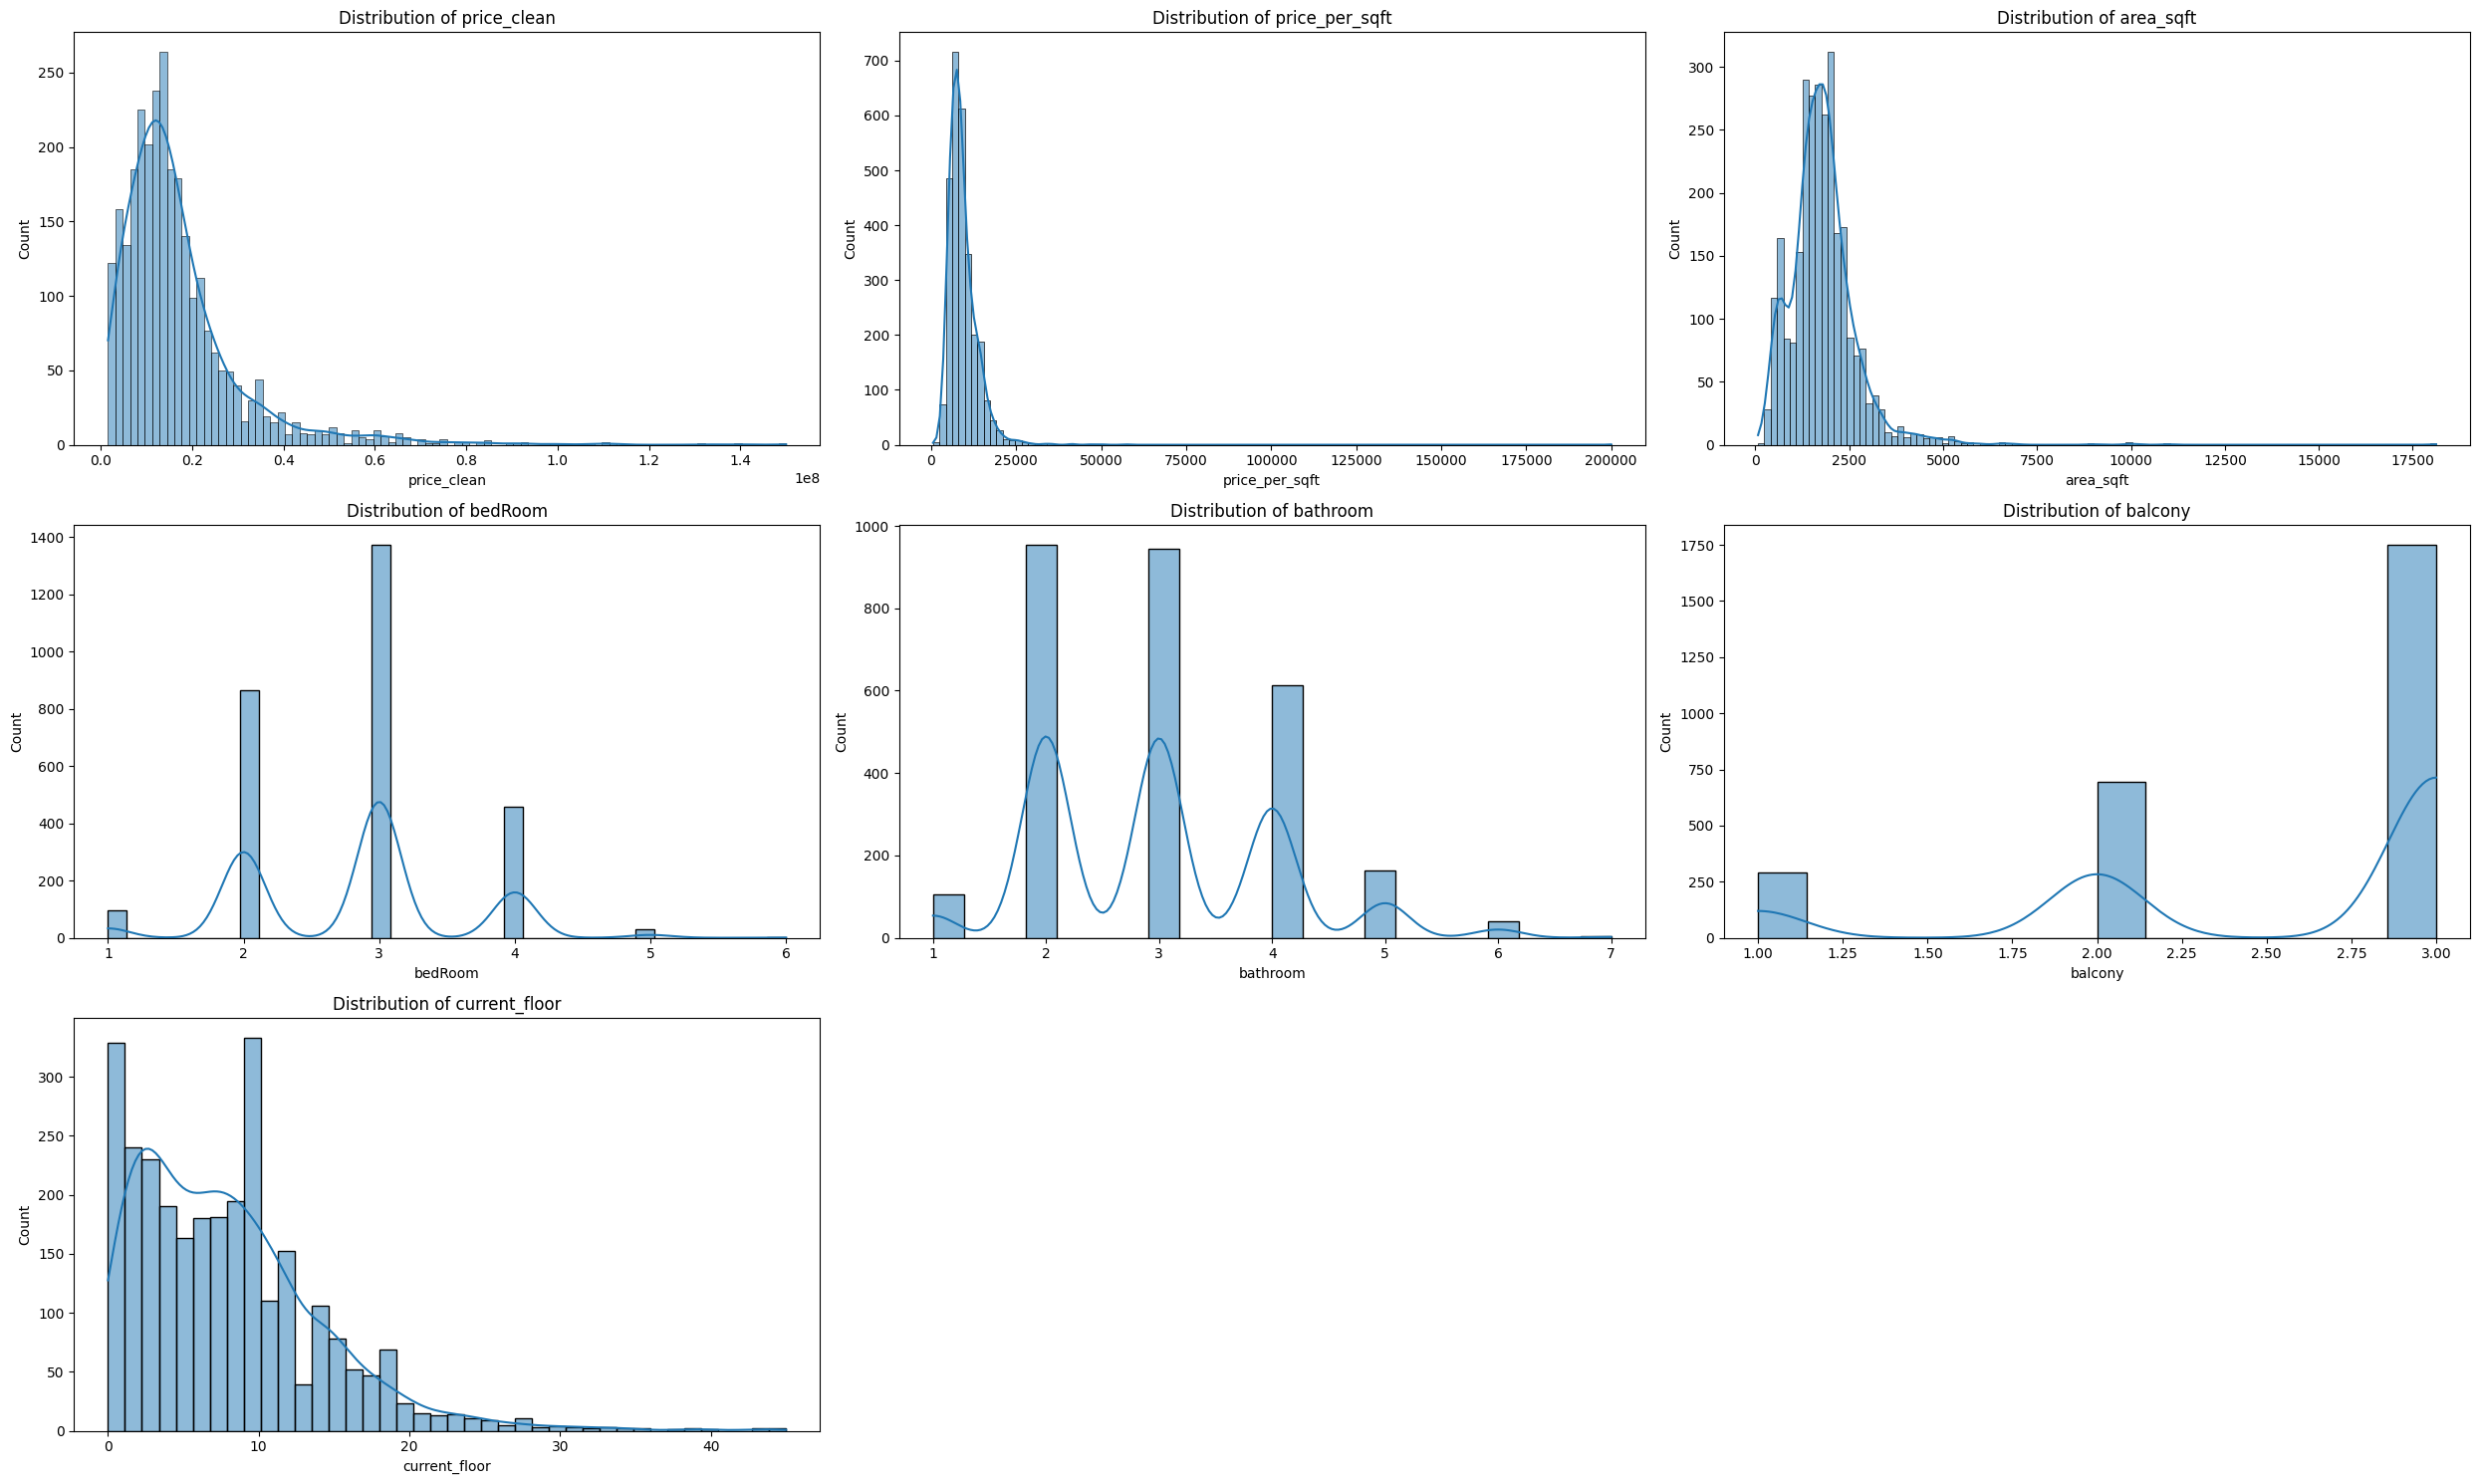

In [59]:
plt.figure(figsize=(25,15))
for e,i in  enumerate(analysis_df.columns[0:7]):
     plt.subplot(3, 3, e + 1)
     plt.title('Distribution of '+ i)
     sns.histplot(analysis_df[i],kde=True)
     plt.tight_layout()
     

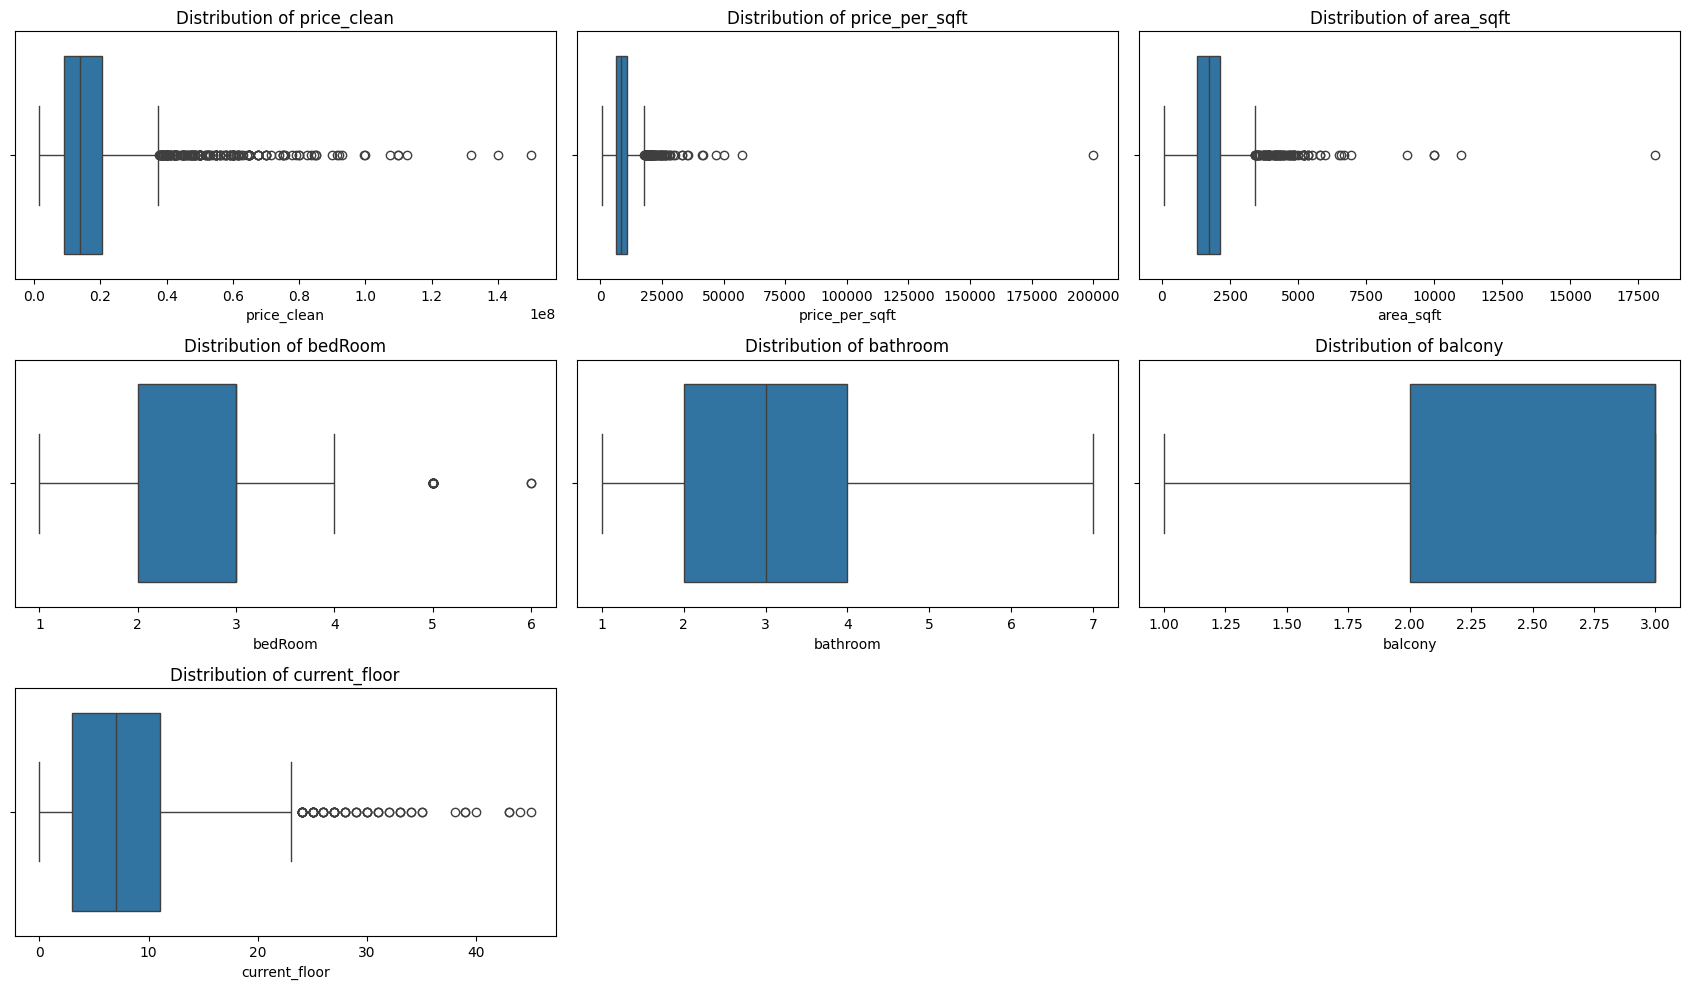

In [60]:
plt.figure(figsize=(17,10))
for e,i in  enumerate(analysis_df.columns[0:7]):
     plt.subplot(3, 3, e + 1)
     plt.title('Distribution of '+ i)
     sns.boxplot(x=analysis_df[i])
     plt.tight_layout()
     

In [61]:
analysis_df.price_per_sqft.describe()

count     2,824.00
mean      9,327.28
std       5,563.80
min         544.00
25%       6,500.00
50%       8,333.00
75%      10,994.50
max     200,000.00
Name: price_per_sqft, dtype: float64

In [62]:
q1 = analysis_df.area_sqft.quantile(0.25)
q2 = analysis_df.area_sqft.median()
q3 = analysis_df.area_sqft.quantile(0.75)

IQR = q3 - q1 

LB = q1 - (IQR * 1.5)
UP = q3 + (IQR * 1.5)

In [63]:
analysis_df[analysis_df['area_sqft'] >= UP ].sort_values(by= 'area_sqft',ascending=False)

,price_clean,price_per_sqft,area_sqft,bedRoom,bathroom,balcony,current_floor,total_floors,floor_ratio,area_type,society_clean
2440,"25,000,000.00","1,379.00","18,122.00",4.00,5.00,3.00,16.00,24.00,0.67,Carpet area,godrej air
1641,"132,000,000.00","12,000.00","11,000.00",4.00,4.00,3.00,13.00,40.00,0.33,Carpet area,m3m golfestate
674,"75,000,000.00","7,500.00","10,000.00",5.00,6.00,3.00,23.00,26.00,0.88,Super Built up area,krrish provence estate
1635,"85,000,000.00","8,500.00","10,000.00",4.00,4.00,3.00,9.00,18.00,0.50,Carpet area,the penthouses at the hibiscus
1637,"80,000,000.00","8,888.00","9,000.00",4.00,3.00,3.00,7.00,18.00,0.39,Carpet area,the penthouses at the hibiscus
1547,"47,000,000.00","6,786.00","6,926.00",4.00,4.00,3.00,19.00,21.00,0.90,Super Built up area,bestech park view grand spa
2211,"150,000,000.00","22,388.00","6,700.00",5.00,6.00,3.00,17.00,17.00,1.00,Carpet area,central park flower valley
811,"60,000,000.00","9,139.00","6,565.00",5.00,6.00,3.00,24.00,24.00,1.00,Carpet area,tata gurgaon gateway
719,"44,500,000.00","6,846.00","6,500.00",4.00,5.00,3.00,27.00,27.00,1.00,Carpet area,ats triumph
1075,"70,000,000.00","11,000.00","6,000.00",4.00,4.00,3.00,6.00,31.00,0.19,Super Built up area,NaN


<Axes: xlabel='area_sqft', ylabel='price_clean'>

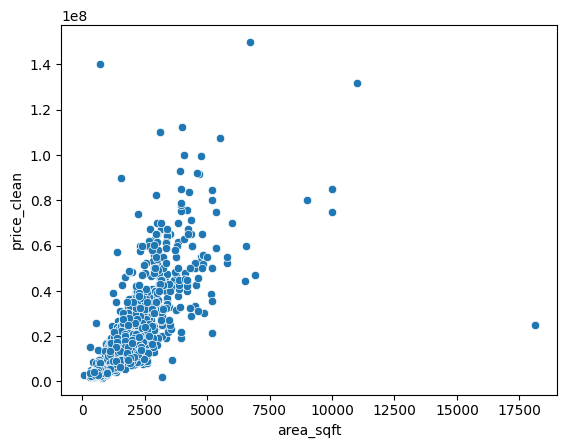

In [64]:
sns.scatterplot(
    data=df,
    x='area_sqft',
    y='price_clean'
)

In [65]:
# Delete outlaires

In [66]:
Q1 = analysis_df.price_clean.quantile(0.25)
Q2 = analysis_df.price_clean.median()
Q3 = analysis_df.price_clean.quantile(0.75)

iqr  = Q3 - Q1 

lb = Q1 - (1.5 * iqr)
up = Q3 + (1.5 * iqr)

In [67]:
analysis_df['Market'] = ['luxury' if  i > up  else 'Standard' for i in df.price_clean]

###  Strategic Market Segmentation: Standard vs. Luxury Real Estate

**Business & Statistical Rationale:**
Standard preprocessing often mandates the outright deletion of outliers to sanitize data. However, in the real estate domain, extreme values in property size (`area`) and price typically signify the highly lucrative **Luxury Segment** (e.g., penthouses, villas, luxury estates) rather than faulty data ingestion. Blindly deleting these records discards high-margin business insights.

To protect the statistical integrity of mainstream market metrics while fully capitalizing on high-net-worth data, we implement an empirical market segmentation. The dataset is dynamically partitioned into two distinct dataframes based on a rigorous statistical threshold—the **Upper Bound (UB)** calculated via the Interquartile Range (IQR) method:

$$\text{IQR} = Q3 - Q1$$
$$\text{Upper Bound} = Q3 + (1.5 \times \text{IQR})$$

* **Standard Market Subsegment:** Sourced from properties within the statistical boundary ($\le$ Upper Bound), forming the baseline for volume-driven market trends.
* **Luxury Market Subsegment:** Captures the 102 statistical outlier records ($>$ Upper Bound) to analyze premium tier real estate behavior independently.

In [68]:
analysis_df

,price_clean,price_per_sqft,area_sqft,bedRoom,bathroom,balcony,current_floor,total_floors,floor_ratio,area_type,society_clean,Market
0,"4,500,000.00","5,000.00",900.00,2.00,2.00,1.00,4.00,4.00,1.00,Carpet area,maa bhagwati residency,Standard
1,"5,000,000.00","7,692.00",650.00,2.00,2.00,1.00,1.00,3.00,0.33,Carpet area,apna enclave,Standard
2,"4,000,000.00","6,722.00",595.00,2.00,2.00,3.00,12.00,14.00,0.86,Carpet area,tulsiani easy in homes,Standard
3,"14,700,000.00","12,250.00","1,200.00",2.00,2.00,2.00,2.00,4.00,0.50,Carpet area,smart world orchard,Standard
4,"7,000,000.00","5,204.00","1,345.00",2.00,2.00,3.00,5.00,8.00,0.62,Super Built up area,parkwood westend,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...
3023,"10,500,000.00","5,541.00","1,895.00",3.00,3.00,3.00,9.00,13.00,0.69,Super Built up area,ansal heights 86,Standard
3024,"33,000,000.00","9,984.00","3,905.00",5.00,5.00,3.00,4.00,5.00,0.80,Super Built up area,parsvnath green ville,Standard
3025,"9,500,000.00","5,214.00","1,822.00",3.00,3.00,3.00,3.00,22.00,0.14,Super Built up area,raheja vedaanta,Standard
3026,"58,000,000.00","12,500.00","3,700.00",3.00,4.00,3.00,9.00,9.00,1.00,Built Up area,ambience lagoon,luxury


### Bivariate 

#### Price VS Society

In [69]:
(analysis_df.groupby('society_clean',as_index=False)['price_per_sqft'].mean()).sort_values(by= 'price_per_sqft' ,ascending=False)

,society_clean,price_per_sqft
20,ambience caitriona,"200,000.00"
243,lig flat,"50,000.00"
131,dlf the crest,"35,352.50"
132,dlf the grove,"33,122.50"
492,tulip monsella,"25,344.25"
...,...,...
200,hsiidc sidco aravali,"3,428.33"
327,prasha apartments,"3,309.00"
329,professional society,"3,067.00"
381,saroop garden,"2,638.00"


<Axes: xlabel='price_clean', ylabel='society_clean'>

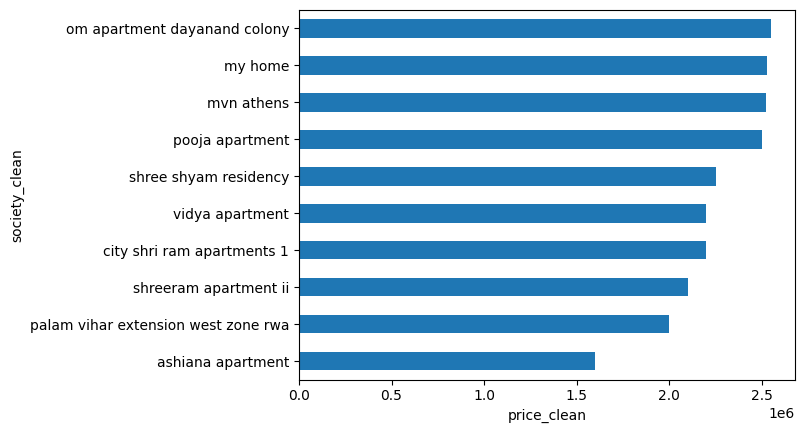

In [70]:
mean_price = analysis_df.groupby('society_clean')['price_clean'].mean().sort_values(ascending=True)
mean_price.head(10).plot(kind= 'barh',xlabel= 'price_clean' ,ylabel='society_clean' ) 

<Axes: xlabel='price_per_sqft', ylabel='society_clean'>

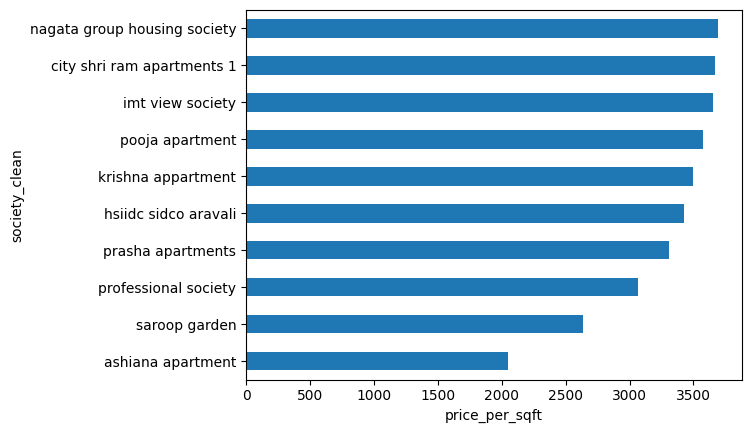

In [71]:
mean_price = analysis_df.groupby('society_clean')['price_per_sqft'].mean().sort_values(ascending=True)
mean_price.head(10).plot(kind= 'barh',xlabel= 'price_per_sqft' ,ylabel='society_clean' ) 

Based on our analysis, using the total price (price_clean) as a benchmark for comparing neighborhoods proves to be a misleading indicator, as it reflects the size of the unit rather than its true market value. A large apartment with a low price per square foot will always appear more expensive than a small apartment with a high price per square foot, distorting any meaningful comparison across areas or property types.
In contrast, price per square foot (price_per_sqft) represents the more accurate and objective measure, as it neutralizes the size effect and enables a fair comparison between neighborhoods regardless of unit size. This was clearly demonstrated when the ranking of neighborhoods differed significantly between the two charts, with the price_per_sqft ranking proving far more consistent with the known market reality of those areas.

#### Area VS Price 

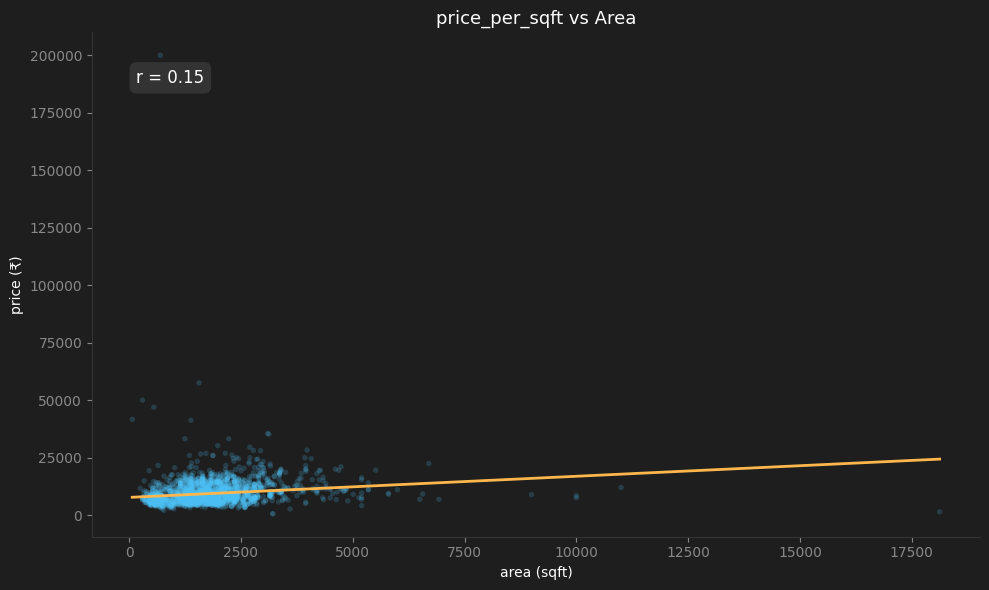

In [72]:
x = analysis_df['area_sqft']
y = analysis_df['price_per_sqft']

slope, intercept, r, *_ = stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x, y, alpha=0.2, color='#4FC3F7', s=15, edgecolors='none')

x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope*x_line + intercept, color='#FFB74D', lw=2)

ax.annotate(f'r = {r:.2f}', xy=(0.05, 0.90), xycoords='axes fraction',
            color='white', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.4', fc='#333', ec='none'))

ax.set_xlabel('area (sqft)', color='white')
ax.set_ylabel('price (₹)', color='white')
ax.set_title('price_per_sqft vs Area', color='white', fontsize=13, fontweight='500')
ax.tick_params(colors='#888')
ax.set_facecolor('#1e1e1e')
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_color('#333')
fig.patch.set_facecolor('#1e1e1e')

plt.tight_layout()
plt.show()

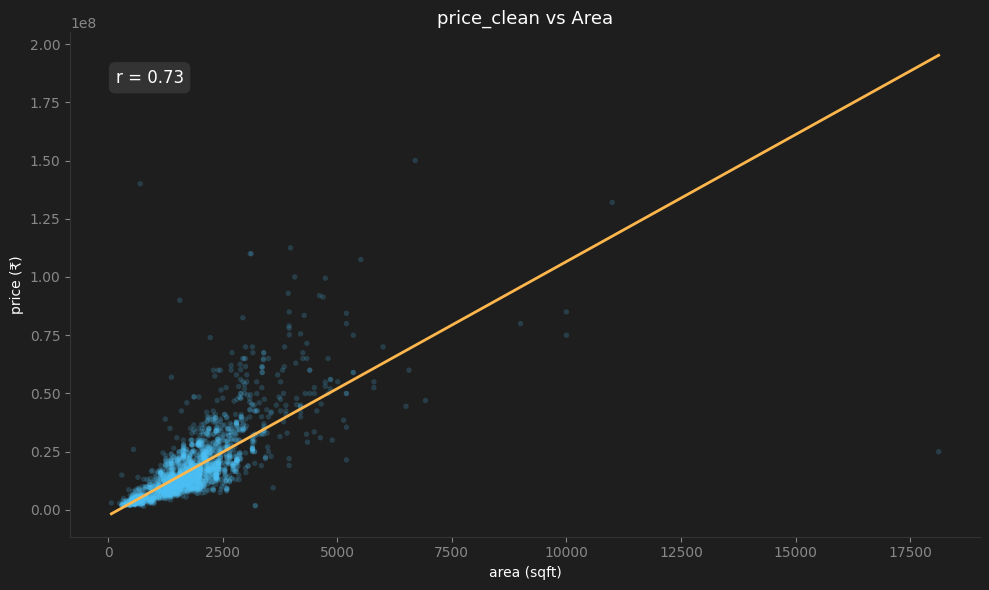

In [73]:
x = analysis_df['area_sqft']
y = analysis_df['price_clean']

slope, intercept, r, *_ = stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x, y, alpha=0.2, color='#4FC3F7', s=15, edgecolors='none')

x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope*x_line + intercept, color='#FFB74D', lw=2)

ax.annotate(f'r = {r:.2f}', xy=(0.05, 0.90), xycoords='axes fraction',
            color='white', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.4', fc='#333', ec='none'))

ax.set_xlabel('area (sqft)', color='white')
ax.set_ylabel('price (₹)', color='white')
ax.set_title('price_clean vs Area', color='white', fontsize=13, fontweight='500')
ax.tick_params(colors='#888')
ax.set_facecolor('#1e1e1e')
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_color('#333')
fig.patch.set_facecolor('#1e1e1e')

plt.tight_layout()
plt.show()

Conclusion:


The strong correlation between price_clean and area_sqft (r = 0.73) is expected and largely tautological — larger units cost more by definition. The more meaningful finding is the near-zero correlation between price_per_sqft and area_sqft (r = 0.15), which indicates that unit size does not drive value per square foot. Pricing efficiency in this market is therefore governed by other factors — most likely location, society quality, or floor level — rather than size alone. This distinction is critical: buyers pay more for larger units, but not necessarily for better-valued ones.

#### Price VS Area_Type

In [74]:
analysis_df.groupby('area_type').agg(
    listings        = ('price_clean',    'count'),
    median_price    = ('price_clean',    'median'),
    avg_price       = ('price_clean',    'mean'),
    median_ppsf     = ('price_per_sqft', 'median'),  # price per sqft
    avg_area        = ('area_sqft',      'mean'),
    median_area     = ('area_sqft',      'median'),
    avg_bedrooms    = ('bedRoom',        'mean'),
    avg_bathrooms   = ('bathroom',       'mean'),
    avg_floors      = ('total_floors',   'mean'),
).round(2).sort_values('median_price', ascending=False)

,listings,median_price,avg_price,median_ppsf,avg_area,median_area,avg_bedrooms,avg_bathrooms,avg_floors
area_type,,,,,,,,,
Super Built up area,1884,"15,000,000.00","18,093,750.53","8,457.00","1,925.84","1,828.00",2.90,3.13,18.74
Built Up area,311,"11,000,000.00","16,582,189.71","7,917.00","1,637.45","1,450.00",2.64,2.67,11.52
Carpet area,629,"10,000,000.00","14,579,672.50","7,963.00","1,482.28","1,300.00",2.62,2.63,12.84


In [75]:
cols = ['price_clean', 'area_sqft']

analysis_df.groupby('area_type')[cols].corr().unstack()['price_clean']['area_sqft'].sort_values(ascending=False)

area_type
Super Built up area   0.78
Carpet area           0.70
Built Up area         0.69
Name: area_sqft, dtype: float64

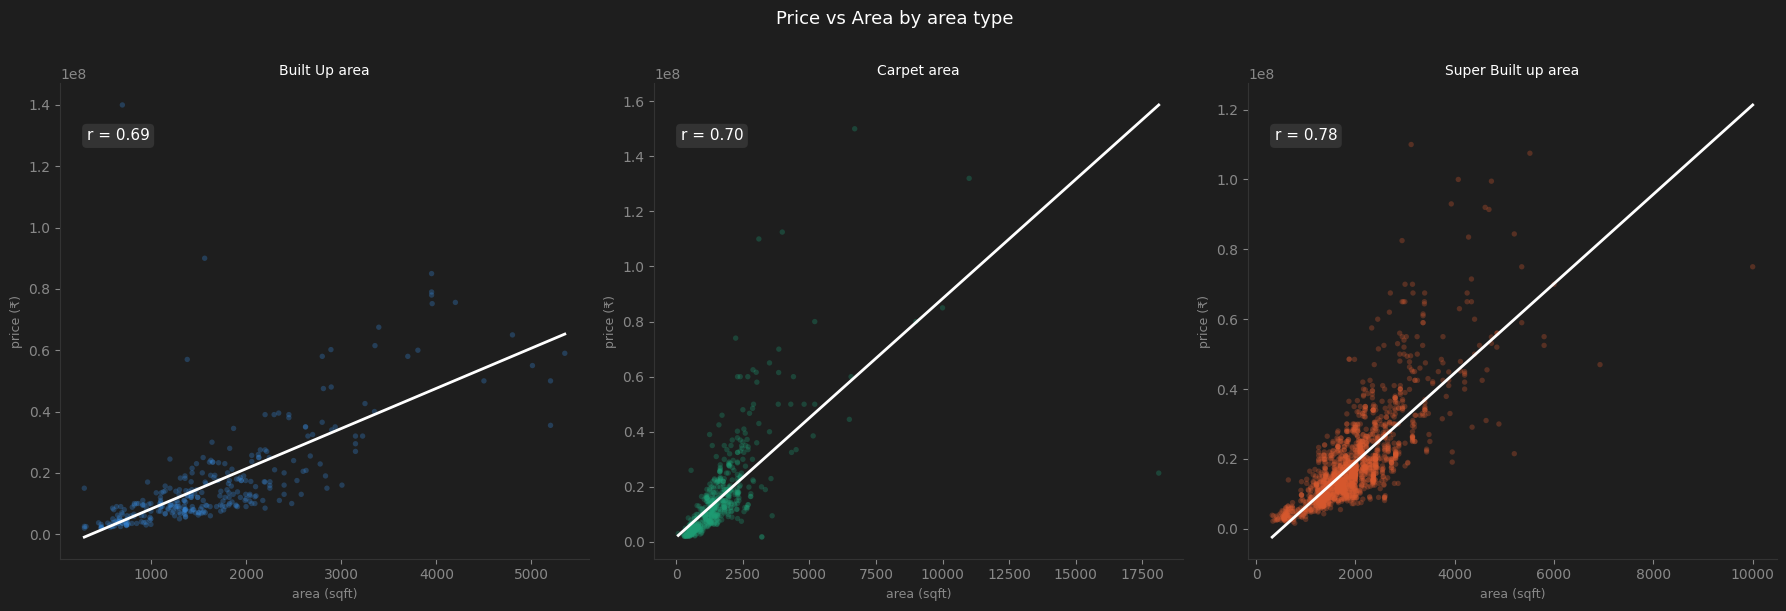

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

types   = ['Built Up area', 'Carpet area', 'Super Built up area']
colors  = ['#378ADD', '#1D9E75', '#D85A30']

for ax, atype, color in zip(axes, types, colors):
    sub = analysis_df[analysis_df['area_type'] == atype].dropna(subset=['area_sqft','price_clean'])
    x, y = sub['area_sqft'], sub['price_clean']

    slope, intercept, r, *_ = stats.linregress(x, y)

    ax.scatter(x, y, alpha=0.3, color=color, s=15, edgecolors='none')
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope*x_line + intercept, color='white', lw=2)

    ax.set_title(atype, color='white', fontsize=10, fontweight='500')
    ax.set_xlabel('area (sqft)', color='#888', fontsize=9)
    ax.set_ylabel('price (₹)', color='#888', fontsize=9)
    ax.annotate(f'r = {r:.2f}', xy=(0.05,0.88), xycoords='axes fraction',
                color='white', fontsize=11,
                bbox=dict(boxstyle='round,pad=0.3', fc='#333', ec='none'))
    ax.tick_params(colors='#888')
    ax.set_facecolor('#1e1e1e')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['bottom','left']].set_color('#333')

fig.patch.set_facecolor('#1e1e1e')
fig.suptitle('Price vs Area by area type', color='white', fontsize=13, fontweight='500', y=1.01)
plt.tight_layout()
plt.show()

Conclusion: 

Super Built-up Area properties achieve the highest prices among all area types, indicating that area type has a significant impact on property value and should be considered a key pricing factor.

#### Price Vs Market

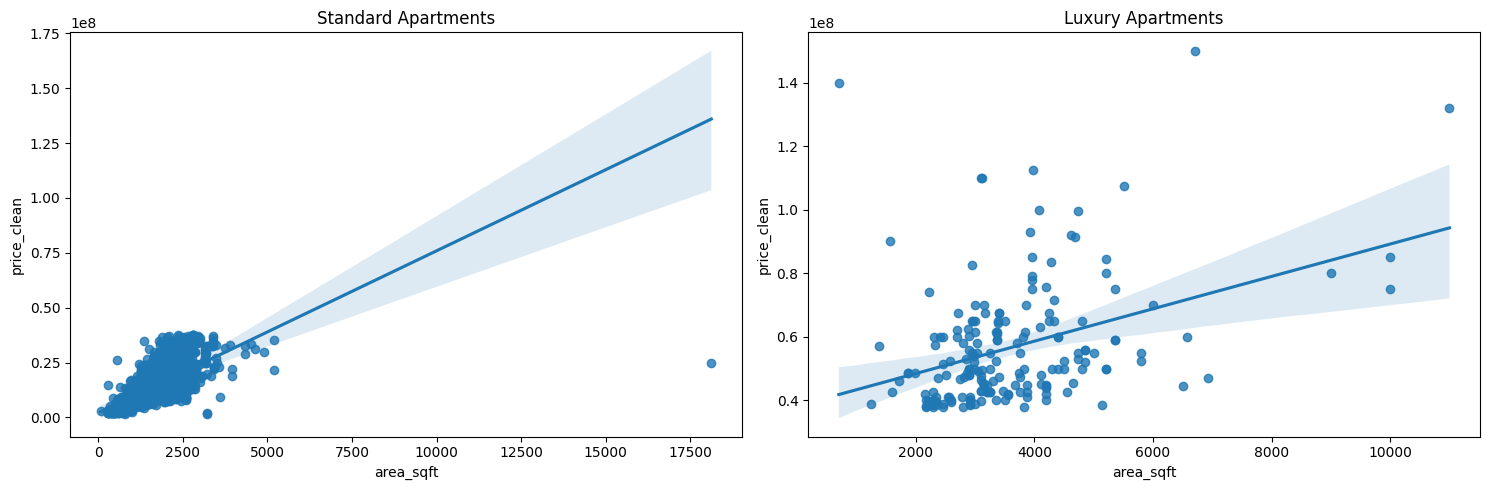

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# الشقق العادية
sns.regplot(data=analysis_df[analysis_df['Market'] == 'Standard'], 
            x='area_sqft', y='price_clean', ax=axes[0])
axes[0].set_title('Standard Apartments')

# الشقق الفاخرة
sns.regplot(data=analysis_df[analysis_df['Market'] == 'luxury'], 
            x='area_sqft', y='price_clean', ax=axes[1])
axes[1].set_title('Luxury Apartments')

plt.tight_layout()
plt.show()

In [78]:
segments = ['luxury', 'Standard']

for segment in segments:
    segment_df = analysis_df[analysis_df['Market'] == segment]
    corr = segment_df[['price_clean', 'area_sqft']].corr()
    print(f"\n{'='*40}")
    print(f"Segment: {segment}  |  Rows: {len(segment_df)}")
    print(corr['price_clean'].sort_values(ascending=False))


Segment: luxury  |  Rows: 188
price_clean   1.00
area_sqft     0.38
Name: price_clean, dtype: float64

Segment: Standard  |  Rows: 2636
price_clean   1.00
area_sqft     0.69
Name: price_clean, dtype: float64


Conclusion:

Area is a meaningful price driver in the Standard segment (r = 0.69), but loses that power in the Luxury segment (r = 0.38), where pricing is governed by factors beyond size — location, finishing, and society prestige.

#### Correlation Coefcient

In [79]:
analysis_df.columns

Index(['price_clean', 'price_per_sqft', 'area_sqft', 'bedRoom', 'bathroom',
       'balcony', 'current_floor', 'total_floors', 'floor_ratio', 'area_type',
       'society_clean', 'Market'],
      dtype='str')

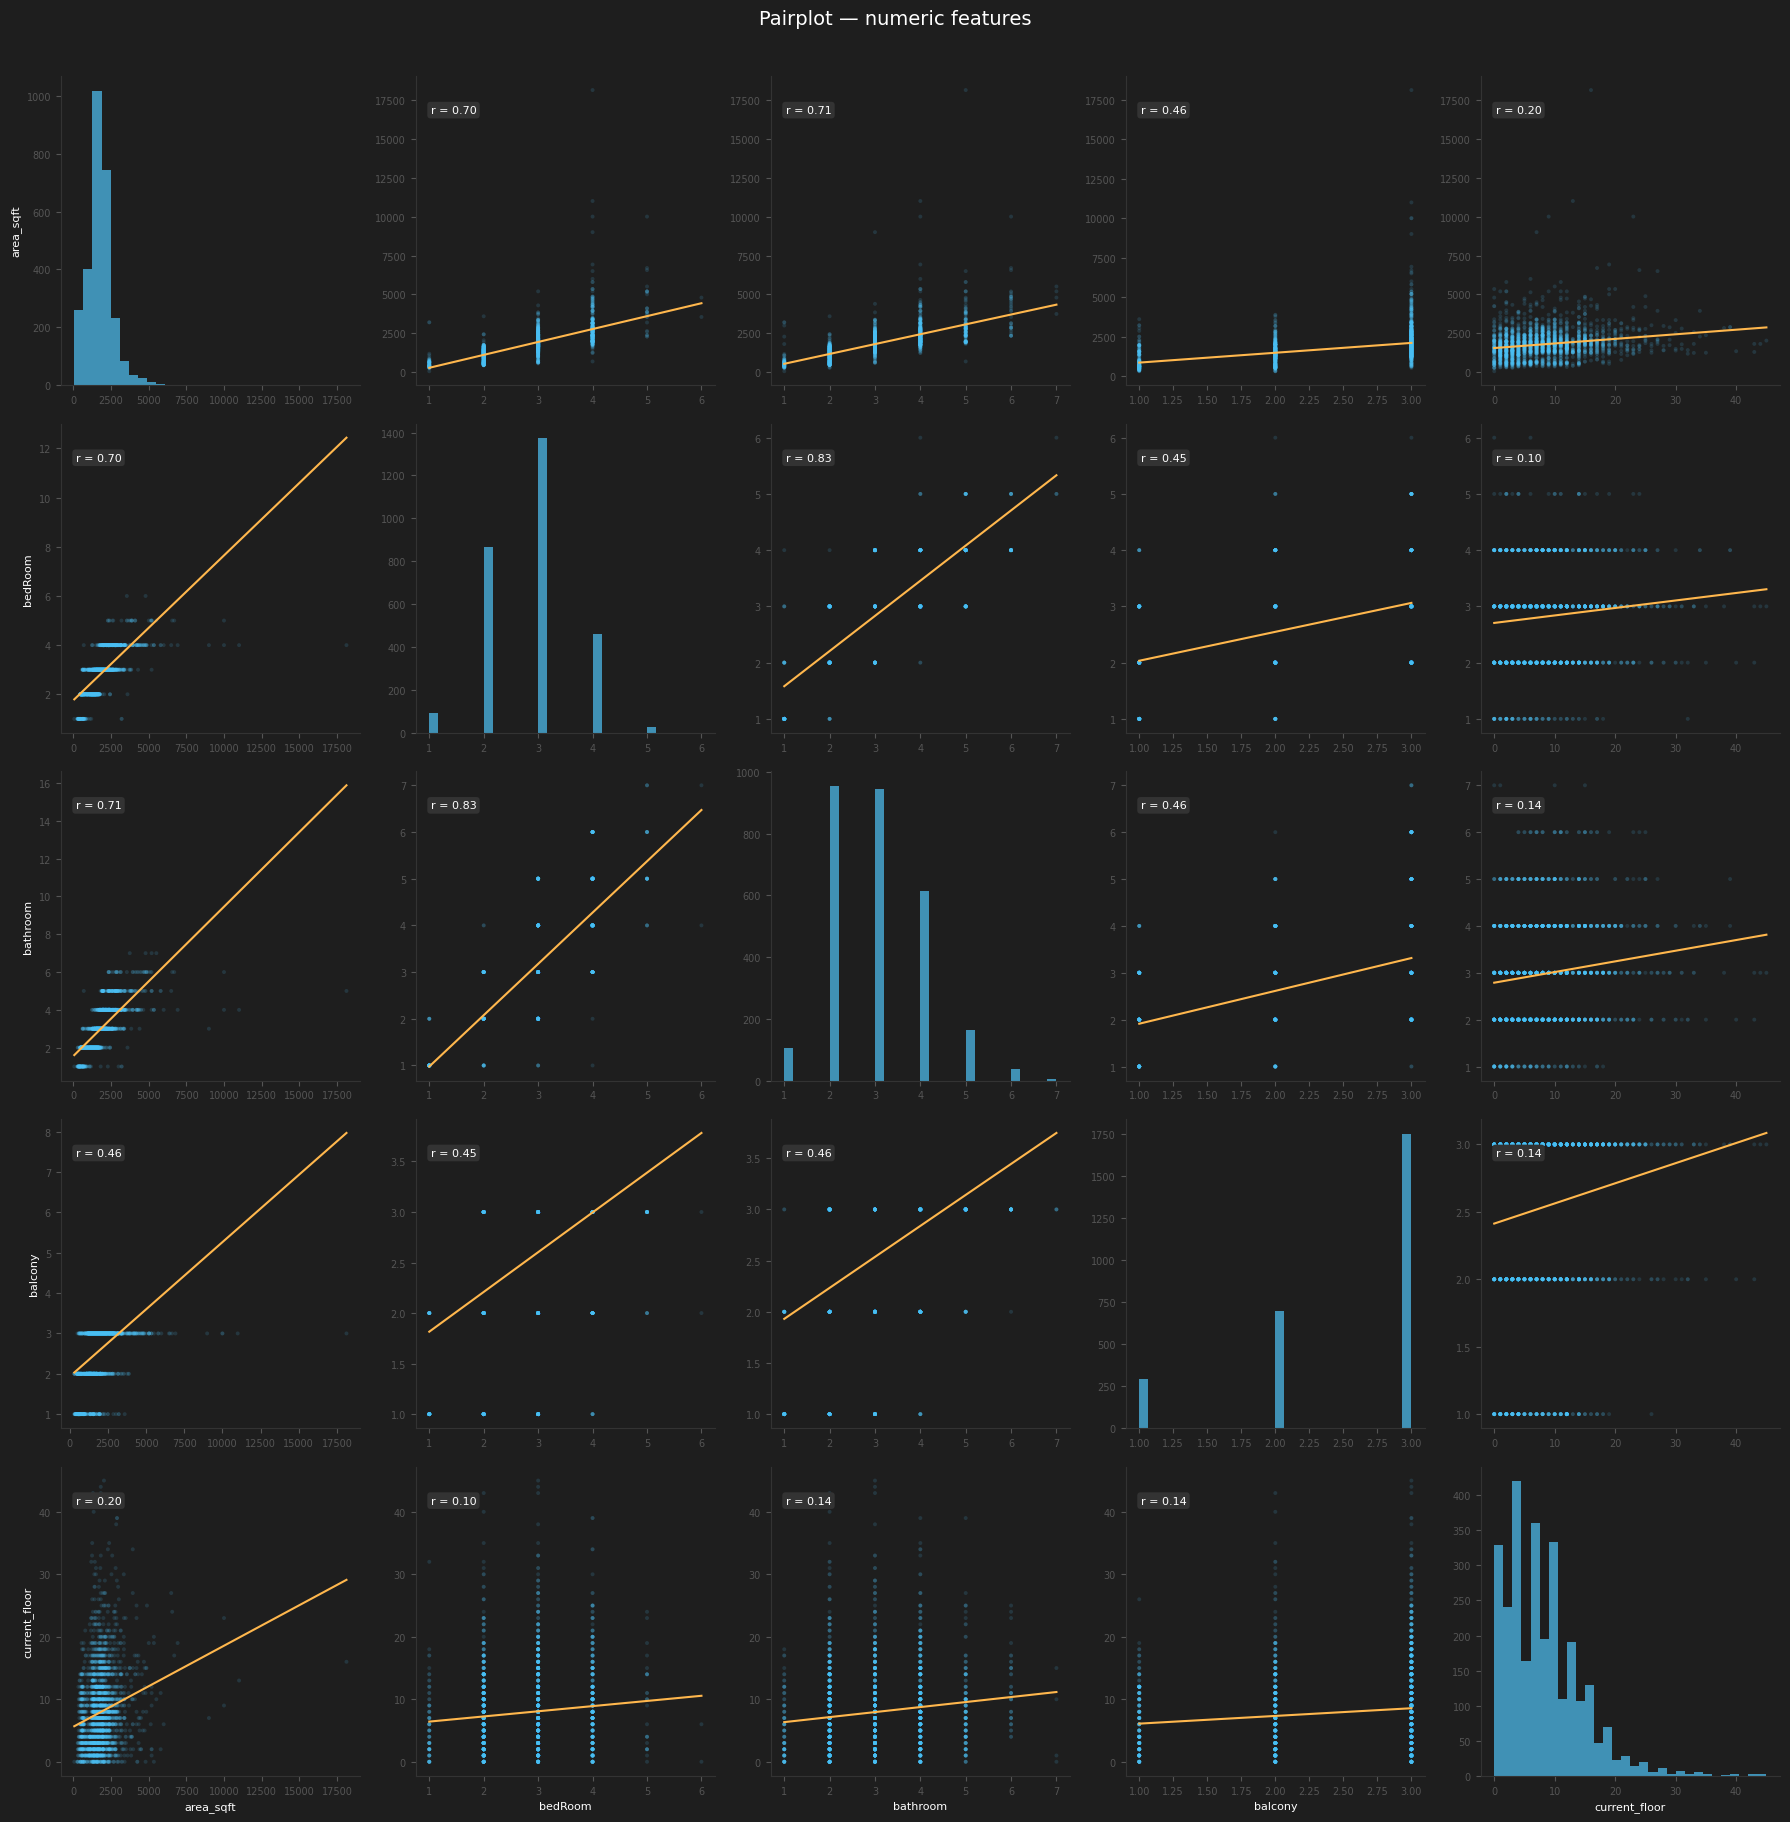

In [80]:
cols = ['area_sqft', 'bedRoom', 'bathroom', 'balcony', 'current_floor']

n = len(cols)
fig, axes = plt.subplots(n, n, figsize=(18, 18))

for i, col_y in enumerate(cols):
    for j, col_x in enumerate(cols):
        ax = axes[i, j]

        idx = analysis_df[[col_x, col_y]].dropna().index
        x = analysis_df.loc[idx, col_x]
        y = analysis_df.loc[idx, col_y]

        if i == j:
            ax.hist(x, bins=30, color='#4FC3F7', alpha=0.7, edgecolor='none')
        else:
            slope, intercept, r, *_ = stats.linregress(x, y)
            ax.scatter(x, y, alpha=0.15, color='#4FC3F7', s=8, edgecolors='none')
            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, slope * x_line + intercept, color='#FFB74D', lw=1.5)

            ax.annotate(f'r = {r:.2f}', xy=(0.05, 0.88),
                        xycoords='axes fraction', color='white', fontsize=8,
                        bbox=dict(boxstyle='round,pad=0.3', fc='#333', ec='none'))

        if i == n - 1:
            ax.set_xlabel(col_x, color='white', fontsize=8)
        if j == 0:
            ax.set_ylabel(col_y, color='white', fontsize=8)

        ax.set_facecolor('#1e1e1e')
        ax.tick_params(colors='#555', labelsize=7)
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines[['bottom', 'left']].set_color('#333')

fig.patch.set_facecolor('#1e1e1e')
plt.suptitle('Pairplot — numeric features', color='white', fontsize=14, fontweight='500', y=1.01)
plt.tight_layout()
plt.show()

In [81]:
corr_matrix = analysis_df[['price_clean', 'area_sqft', 'bedRoom', 'bathroom', 'balcony', 'current_floor', 'floor_ratio']].corr()
print(corr_matrix['price_clean'].sort_values(ascending=False))

price_clean      1.00
area_sqft        0.73
bathroom         0.59
bedRoom          0.55
balcony          0.35
current_floor    0.21
floor_ratio     -0.02
Name: price_clean, dtype: float64


<Axes: >

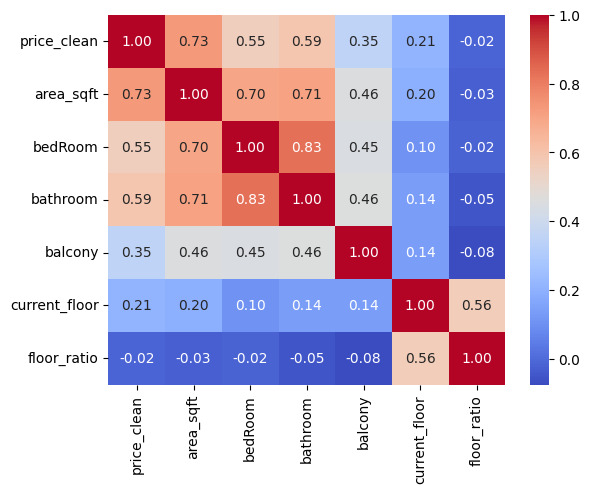

In [82]:
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')

Property size is the strongest numerical driver of apartment prices (r=0.73), followed by bathroom count (r=0.59) and bedroom count (r=0.55). Floor position shows minimal influence, while floor ratio exhibits virtually no linear relationship with price, suggesting it may not be a meaningful predictor for valuation models.

### Multlivariate analysis 

#### Price Distribution by Area Type and Market

<Axes: xlabel='Market', ylabel='price_clean'>

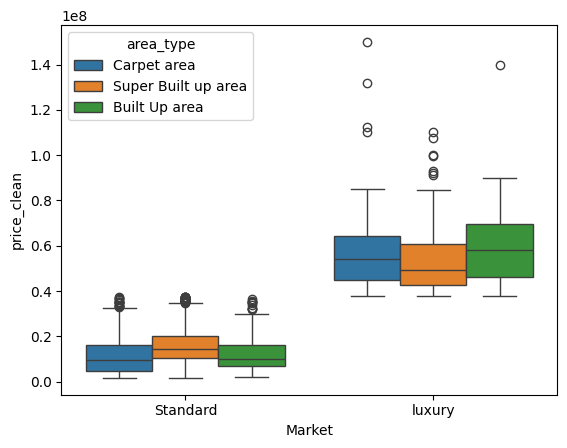

In [83]:
sns.boxplot(
    data=analysis_df,
    x='Market',
    y='price_clean',
    hue='area_type'
)

Property prices vary significantly across market segments and area types. Luxury properties consistently achieve higher prices than standard properties regardless of area classification. Among luxury properties, Built-up Area units exhibit the highest median prices, while the wide spread of prices and numerous outliers indicate substantial variation within the luxury segment.

#### Area vs Price by Market

<Axes: xlabel='area_sqft', ylabel='price_clean'>

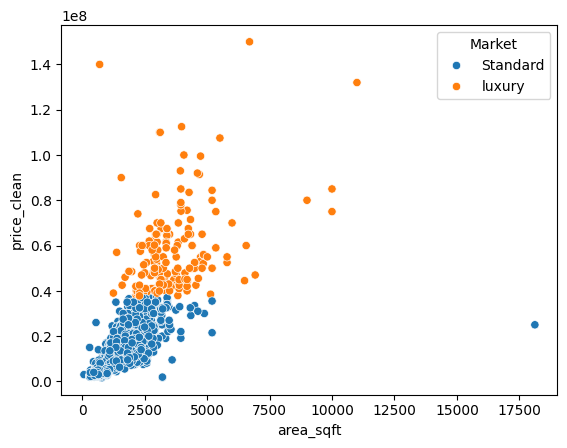

In [84]:
sns.scatterplot( 
    data= analysis_df,
    x='area_sqft',
    y='price_clean',
    hue='Market'
)

Property size shows a positive relationship with price across both market segments. However, luxury properties command substantially higher prices than standard properties even at similar sizes, suggesting that market positioning contributes significantly to property valuation beyond physical area alone.

#### Median Price by Bedrooms and Bathrooms

In [85]:
pivot = pd.pivot_table(
    analysis_df,
    values='price_clean',
    index='bedRoom',
    columns='bathroom',
    aggfunc='median'
)

pivot

bathroom,1.00,2.00,3.00,4.00,5.00,6.00,7.00
bedRoom,,,,,,,
1.00,"3,755,000.00","5,500,000.00",NaN,NaN,NaN,NaN,NaN
2.00,"4,100,000.00","8,025,000.00","9,650,000.00","12,000,000.00",NaN,NaN,NaN
3.00,"10,250,000.00","9,700,000.00","15,400,000.00","19,300,000.00","16,400,000.00",NaN,NaN
4.00,"16,000,000.00","9,000,000.00","16,450,000.00","21,350,000.00","30,250,000.00","31,000,000.00",NaN
5.00,NaN,NaN,NaN,"28,600,000.00","41,750,000.00","57,500,000.00","50,000,000.00"
6.00,NaN,NaN,NaN,"23,000,000.00",NaN,NaN,"50,000,000.00"


In [86]:
pivot = pd.pivot_table(
    analysis_df,
    values='price_clean',
    index='bedRoom',
    columns='bathroom',
    aggfunc='median'
) / 1000000

<Axes: xlabel='bathroom', ylabel='bedRoom'>

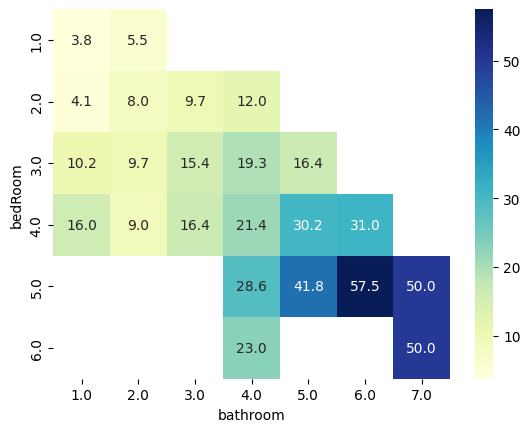

In [87]:
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu'
)

Property prices generally increase with the number of bedrooms and bathrooms. The highest median prices are observed in properties offering five bedrooms and five bathrooms, highlighting the strong influence of property configuration and living capacity on market value.

## 8. Key Insights

The analysis indicates that society is the strongest driver of property prices overall, followed by the number of bedrooms and then bathrooms. For standard properties, area size emerges as the most influential factor, surpassing other property characteristics. In contrast, for luxury properties, society becomes the dominant pricing factor, with its impact being even stronger than in the standard market segment.

Additionally, properties with 5 bedrooms and 6 bathrooms record the highest median price at approximately 57.5 million, exceeding even larger configurations such as 6 bedrooms and 7 bathrooms, which have a median price of around 40 million. This suggests that premium property value is not determined solely by the number of rooms, but also by factors such as society, market positioning, and overall property desirability.

## 9. Business Questions and Answers

Q1: What factors have the strongest relationship with property prices?
Answer: Property size is the single most dominant factor determining price across the entire dataset. This is followed closely by location-specific variables, specifically the clean society name and internal configuration layouts (the combination of bedrooms and bathrooms).

Q2: How does property size influence market value?
Answer: The relationship is highly dependent on market stratification. In the Standard Segment, price scales linearly and predictably with square footage. However, in the Luxury Segment, the premium per square foot scales exponentially, compounding with premium location factors to drive sharp, non-linear price spikes.

Q3: Are luxury properties significantly different from standard properties?
Answer: Yes, statistically and economically. Luxury properties (isolated using the Interquartile Range (IQR) method on price and area) operate in a completely separate micro-market. Their valuation is driven by exclusivity, premium society reputation, and asset desirability rather than the raw baseline per-square-foot calculations that govern the standard market.

Q4: Do higher-floor apartments command higher prices?
Answer: No, the floor level does not serve as a primary price driver independently. While floor height can influence specific premium apartment views, its overall statistical weight is negligible compared to the overwhelming impact of society prestige, size, and geographic location.

Q5: How do bedroom counts affect pricing?
Answer: The data reveals a clear non-linear anomaly at the high end of the market. Properties with a 5-bedroom, 6-bathroom configuration command the highest median price at approximately 57.5 million, outperforming larger 6-bedroom, 7-bathroom configurations which drop to a median of 40 million. This proves that premium market positioning and society exclusivity outweigh raw room count.

Q6: Which area measurement type is associated with higher property values?
Answer: Super built-up and plot areas verified within Tier-1 premium societies correlate with the highest property values. Buyers in this segment pay a massive premium for documented, fully utilized space within high-end gated developments rather than unverified independent measurements.

## 10. Business Recommendations

The size of a standard apartment should be considered a key factor in determining its price. The location should be a key factor in determining the price of luxury apartments. The number of bedrooms and bathrooms should also be considered factors influencing property prices.